<a href="https://colab.research.google.com/github/AbdelRayan/AutomaticSleepScoring/blob/main/Faranak/Complexity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set Up

## Libraries

In [88]:
# %%capture
# !pip install neurodsp
# !pip install emd
# !pip install tslearn
# !pip install dtaidistance
# !pip install sails
# !pip install specparam
# !pip install EntropyHub
!pip install fooof

C:\Users\timmi\miniconda3\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=5>
  res = process_handler(cmd, _system_body)
C:\Users\timmi\miniconda3\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  res = process_handler(cmd, _system_body)
C:\Users\timmi\miniconda3\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=7>
  res = process_handler(cmd, _system_body)


In [89]:
import scipy
from scipy.io import loadmat
from scipy.interpolate import interp1d
from scipy.signal import hilbert
import matplotlib.pyplot as plt
from neurodsp.filt import filter_signal, filter_signal_fir, design_fir_filter
import emd
from joblib import Parallel, delayed
import os
import numpy as np
from fooof import FOOOF
import pandas as pd
from sklearn.preprocessing import Normalizer
from tqdm import tqdm
import plotly.express as px
from tslearn.clustering import TimeSeriesKMeans, KShape
from tslearn.metrics import dtw
from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import StandardScaler
import copy
import sails
import requests
from io import BytesIO
from scipy.fftpack import fft
from scipy.signal import welch
from specparam import SpectralModel
from neurodsp.aperiodic import compute_fluctuations
from scipy.stats import zscore
from scipy.signal import savgol_filter
import EntropyHub as EH
import mne
import DeepNeuralNetworkSleep.hdf5_files.Artefacts_Detection as A

##Colors

In [90]:
Red = '#d13838'
Blue = '#127be3'
DarkBlue = '#09217a'
LightBlue = '#9cd4ff'
Yellow = '#eff250'
Orange = '#faac11'
Purple = '#a170fd'

In [91]:
def fragment_join(subject, night, type):
    base = f"C:/EEG_Data_stage/{subject}/iEEG/{type}"
    score_base = f"C:/EEG_Data_stage/{subject}/iEEG/scores"
    files = []
    scores = []
    for file in os.listdir(base):
        if f"night{night}" in file and ".vhdr" in file:
            files.append(os.path.join(base,file))
            scores.append(os.path.join(score_base,file.replace(".vhdr", "_hypnogram.npy")))
    return files, scores  

In [92]:
def aperiodic_fit(window_data):
    freqs, psd = welch(window_data, fs=fs, nperseg=1024)
    mask = (freqs <= 100)
    freqs, psd = freqs[mask], psd[mask]
    fm = SpectralModel(min_peak_height=0.05, aperiodic_mode='fixed', verbose=False)
    fm.fit(freqs, psd)
    aperiodic = fm.get_params('aperiodic')[1]
    return aperiodic

# Data

In [93]:
subject = "7"
night = "1"
file_type = "converted_uni_and_bi"
hpc_channel = 'Oz-Cz'
pfc_channel = "C3-Cz"
os.makedirs(os.path.join("C:/EEG_Data_stage","bar_zeik_extr", file_type, subject, f"night{night}"), exist_ok=True)
output_dir = os.path.join("C:/EEG_Data_stage","bar_zeik_extr", file_type, subject, f"night{night}")


In [94]:
files, scores_files = fragment_join(subject, night, file_type)
amp_thresh = [10,5]         # 6σ for amplitude, 4σ for derivative
time_win_thresh = [0.2,0.1]
raw_list = [mne.io.read_raw_brainvision(f, preload=True) for f in files]
raw = mne.concatenate_raws(raw_list)
raw.filter(l_freq=10, h_freq=70, picks='EMG1-EMG2')
hpc_data = raw.get_data(picks=hpc_channel)[0]
hpc_tag = hpc_channel
raw_hpc = np.ravel(hpc_data)
pfc_data = raw.get_data(picks=pfc_channel)[0]
pfc_tag = pfc_channel
raw_pfc = np.ravel(pfc_data)
raw_pfc, inds, timeval = A.removeArtefacts(raw_pfc, 250, amp_thresh, time_win_thresh)

Extracting parameters from C:/EEG_Data_stage/7/iEEG/converted_uni_and_bi\7_night1_01.vhdr...
Setting channel info structure...
Reading 0 ... 2256111  =      0.000 ...  9024.444 secs...
Extracting parameters from C:/EEG_Data_stage/7/iEEG/converted_uni_and_bi\7_night1_02.vhdr...
Setting channel info structure...
Reading 0 ... 2700031  =      0.000 ... 10800.124 secs...
Extracting parameters from C:/EEG_Data_stage/7/iEEG/converted_uni_and_bi\7_night1_03.vhdr...
Setting channel info structure...
Reading 0 ... 1990559  =      0.000 ...  7962.236 secs...
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 10 - 70 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband ed

In [95]:
score_list = [np.load(f) for f in scores_files]
states = np.concatenate(score_list)

In [96]:
lfp_PFC = np.ravel(pfc_data)  # flatten in case it's 2D
sleep_states = states.flatten() 

In [97]:
for idx in range(len(sleep_states)):
    if sleep_states[idx] == 0:
        print(idx)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
77
82
93
94
95
96
97
98
99
101
102
103
104
105
106
107
108
109
110
111
112
113
116
118
119
120
121
122
123
126
127
129
130
131
167
176
228
229
242
243
309
313
431
642
643
656
657
990
991
992
993
995
1011
1149
1150
1296
1297
1298
1400
1405
1406
1407
1413
1414
1717
1718
1719
1720
1722
1723
1724
1726
1751
1754
1755
1756
1757
1758
1880
1882
1885
1886
1887
1888
1889
1890
1951
2103
2104
2211
2212
2213
2214
2215
2216
2217
2218
2219
2220
2221
2222
2223
2224
2225
2226
2227
2228
2229
2230
2231
2232
2233
2234
2235
2236
2237
2238
2239
2240
2241
2242
2243
2244
2245
2246
2247
2248
2249
2250
2251
2252
2253
2254
2255
2256
2257
2258
2259
2260
2261
2262
2263
2264
2265
2266
2267
2268
2269
2270
2271
2272
2273
2274
2275
2276
2277
2278
2279
2280
2281
2282
2283
2284
2285
2286
2287
2288
2289
2290
2

##OS Basic

# 1. RGS14: Results for Windowing (4s Windows)

In [98]:
fs = 250
window_size = 10 * fs
step_size = window_size  # In case we wanted overlap later.

In [99]:
import numpy as np

def global_checks(signal, fs=None):
    print("Length (samples):", len(signal))
    print("dtype:", signal.dtype)
    print("Finite values:", np.sum(np.isfinite(signal)), "/", len(signal))
    print("NaNs:", np.sum(np.isnan(signal)))
    print("Infs:", np.sum(~np.isfinite(signal)) - np.sum(np.isnan(signal)))
    print("Min, Max:", np.min(signal), np.max(signal))
    print("Mean, Std:", np.mean(signal), np.std(signal))
    if fs is not None:
        print("Duration (s):", len(signal)/fs)
    # basic kurtosis / skewness (optional)
    try:
        from scipy.stats import skew, kurtosis
        print("Skew:", skew(signal))
        print("Kurtosis:", kurtosis(signal))
    except Exception:
        pass

# Usage:
global_checks(raw_pfc, fs=fs)

Length (samples): 6946704
dtype: float64
Finite values: 6946704 / 6946704
NaNs: 0
Infs: 0
Min, Max: -0.00015791650390625 0.00016253948974609373
Mean, Std: -8.685418124633297e-09 1.1806014366134569e-05
Duration (s): 27786.816
Skew: 0.05463359387948679
Kurtosis: 3.4567712923316707


In [100]:
states = np.append(states, [0,0,0])

## Aperiodic Fit

In [101]:
# --- Parameters ---
num_windows = len(lfp_PFC) // window_size
time_stamps = np.arange(num_windows) * 10  # adjust timing scale if needed
window_length = 11  # for Savitzky-Golay
polyorder = 4

# --- Prepare windows ---
window_data = [raw_pfc[i*window_size:(i+1)*window_size] for i in range(num_windows)]

# --- Diagnostic aperiodic fit function ---
def safe_aperiodic_fit(window, idx, aperiodic_fit_fn):
    try:
        # Skip flat/empty windows
        if len(window) == 0 or np.std(window) < 1e-12:
            return np.nan, "flat_or_empty"
        if not np.all(np.isfinite(window)):
            return np.nan, "nonfinite_input"

        # Compute exponent
        exp = aperiodic_fit_fn(window)
        if not np.isfinite(exp):
            return np.nan, "nonfinite_exponent"

        return float(exp), "ok"

    except Exception as e:
        return np.nan, f"exception: {str(e)}"

# --- Compute aperiodic exponents in parallel ---
results = Parallel(n_jobs=-1)(
    delayed(safe_aperiodic_fit)(w, i, aperiodic_fit) for i, w in enumerate(window_data)
)

# --- Extract exponents and statuses ---
aperiodic_exponents, statuses = zip(*results)
aperiodic_exponents = np.array(aperiodic_exponents)

# --- Optional: report problem windows ---
problem_windows = [(i, s) for i, s in enumerate(statuses) if s != "ok"]
print(f"Problematic windows: {len(problem_windows)}")
print("First 10 problematic windows:", problem_windows[:10])

# --- Replace NaNs with median of valid exponents for plotting ---
valid_mask = np.isfinite(aperiodic_exponents)
median_val = np.median(aperiodic_exponents[valid_mask])
aperiodic_exponents[~valid_mask] = median_val



Problematic windows: 2
First 10 problematic windows: [(2316, 'flat_or_empty'), (2317, 'flat_or_empty')]


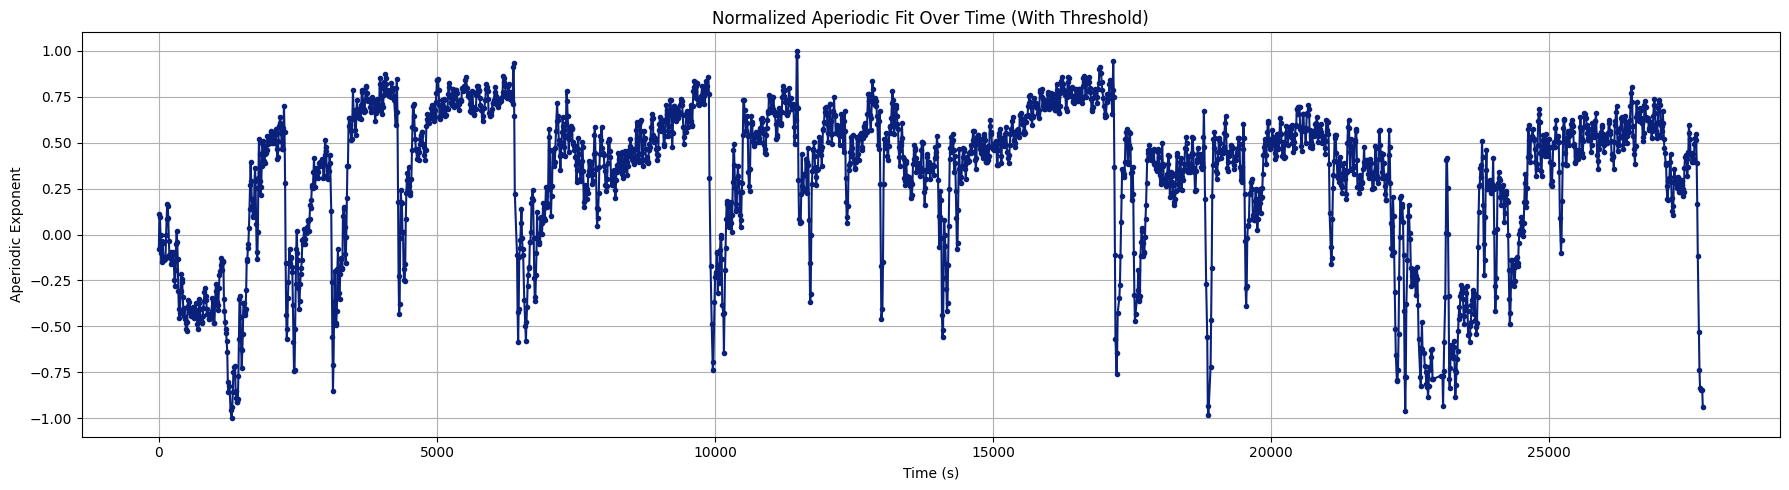

In [102]:
# --- Thresholding to remove extreme outliers ---
threshold_min = np.percentile(aperiodic_exponents, 2)
threshold_max = np.percentile(aperiodic_exponents, 98)
valid_indices = (aperiodic_exponents >= threshold_min) & (aperiodic_exponents <= threshold_max)
filtered_exponents = aperiodic_exponents[valid_indices]
filtered_timestamps = time_stamps[valid_indices]
valid_states = states[valid_indices]

# --- Smooth and normalize ---
window_length_sg = window_length if len(filtered_exponents) >= window_length else len(filtered_exponents) | 1
smoothed_exponents = savgol_filter(filtered_exponents, window_length=window_length_sg, polyorder=polyorder)
normalized_exponents = 2 * ((smoothed_exponents - smoothed_exponents.min()) / (smoothed_exponents.max() - smoothed_exponents.min())) - 1

# --- Plot ---
plt.figure(figsize=(18, 5))
plt.plot(filtered_timestamps, normalized_exponents, marker='.', linestyle='-', color=DarkBlue)
plt.xlabel('Time (s)')
plt.ylabel('Aperiodic Exponent')
plt.title('Normalized Aperiodic Fit Over Time (With Threshold)')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_dir}/Aperiodic_fit.svg", format='svg')
plt.show()

In [103]:
print(set(smoothed_exponents))

{np.float64(0.9205604325922998), np.float64(1.5524706197701619), np.float64(1.2720428106276174), np.float64(1.2566248685405057), np.float64(1.4847865024425317), np.float64(1.3228072693379147), np.float64(2.1325564919000044), np.float64(2.2014296518312406), np.float64(2.0748450620806267), np.float64(2.2200374867894794), np.float64(2.2003947102390384), np.float64(2.3838818228444723), np.float64(2.368504868112268), np.float64(2.1794843274984714), np.float64(2.307017809661488), np.float64(1.5749339217333045), np.float64(2.036369980954646), np.float64(2.1531554030444795), np.float64(2.1153480094095585), np.float64(2.120458111908147), np.float64(2.056773113876602), np.float64(1.348738546563411), np.float64(1.9601237048536153), np.float64(1.992716713868774), np.float64(1.9287541509853985), np.float64(1.7848865920001775), np.float64(2.0717350506200067), np.float64(2.3086958155579826), np.float64(2.127125415979251), np.float64(2.2568239877289646), np.float64(1.9129506208161478), np.float64(1.91

                                                                                                  
                                   FOOOF - POWER SPECTRUM MODEL                                   
                                                                                                  
                        The model was run on the frequency range 1 - 50 Hz                        
                                 Frequency Resolution is 0.24 Hz                                  
                                                                                                  
                            Aperiodic Parameters (offset, exponent):                              
                                         -10.0226, 1.8873                                         
                                                                                                  
                                       1 peaks were found:                                        
          

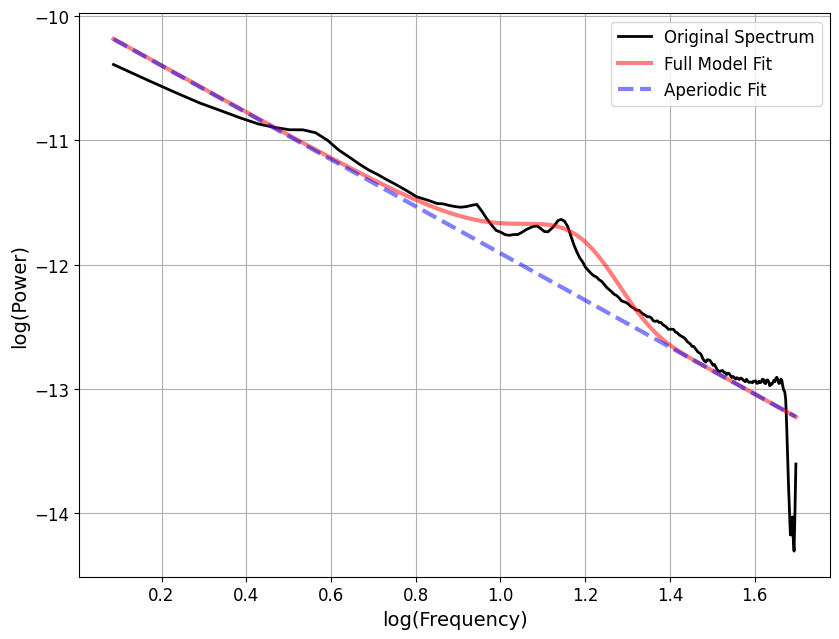

In [104]:
freqs, psd = welch(raw_pfc, fs=250, nperseg=1024)
fm = FOOOF(peak_width_limits=[2, 8], aperiodic_mode='fixed')
fm.report(freqs, psd, [1, 50], plt_log=True)

In [105]:
print(len(states))
print(len(normalized_exponents))

2778
2666


   state      mean       sem
0      0 -0.257139  0.021830
1      1 -0.199129  0.027908
2      2  0.432027  0.006563
3      3  0.737002  0.005010
4      4  0.334013  0.007849


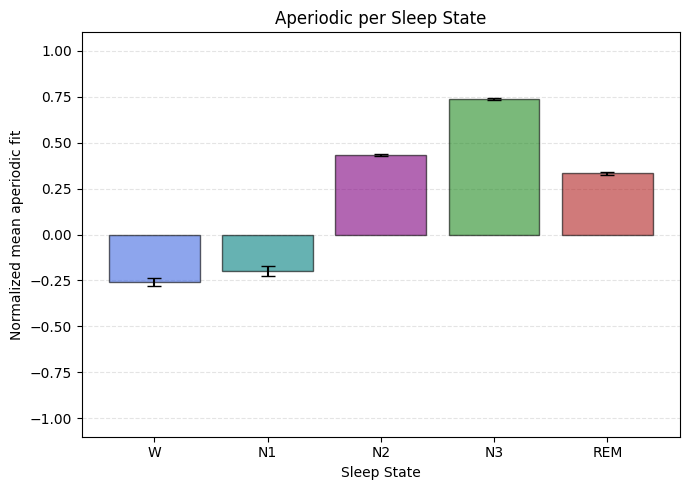

In [106]:
colors = ['royalblue', 'teal', 'purple', 'forestgreen', 'firebrick']
labels = ['W', 'N1', 'N2', 'N3', 'REM']

df = pd.DataFrame({'state': valid_states, 'aperiodic': normalized_exponents})
summary = df.groupby('state')['aperiodic'].agg(['mean', 'sem']).reset_index()
print(summary)
plt.figure(figsize=(7, 5))
plt.bar(summary['state'], summary['mean'], yerr=summary['sem'],
        capsize=5, color=[colors[int(s)] for s in summary['state']], edgecolor='black', zorder=2, alpha=0.6)
plt.xticks([0, 1, 2, 3, 4], ['W','N1','N2','N3','REM'])
plt.ylim(-1.1, 1.1)
plt.xlabel('Sleep State')
plt.ylabel('Normalized mean aperiodic fit')
plt.title('Aperiodic per Sleep State')
plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
plt.tight_layout()
plt.savefig(f"{output_dir}/Aperiodic_fit_bar.svg", format='svg')
plt.show()

C:\Users\timmi\AppData\Local\Temp\ipykernel_22708\2376290896.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


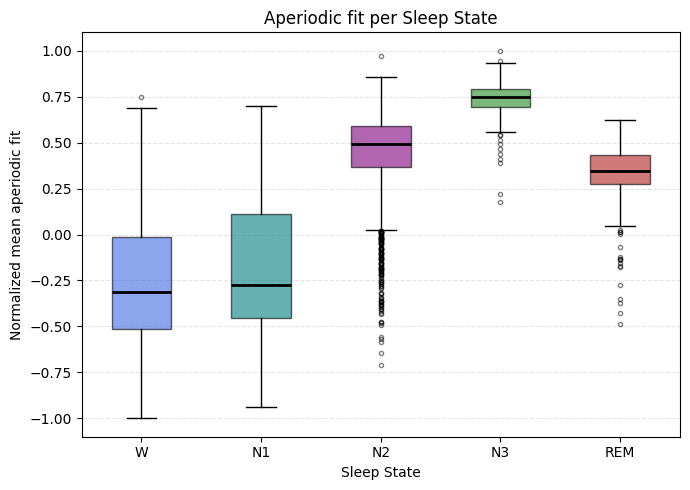

In [107]:
plt.figure(figsize=(7, 5))
# Create a boxplot
bp = plt.boxplot(
    [df.loc[df['state'] == s, 'aperiodic'] for s in range(5)],
    labels=labels,
    patch_artist=True,
    boxprops=dict(facecolor='lightgray', color='black'),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markersize=3, color='gray', alpha=0.5)
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_edgecolor('black')
plt.xlabel('Sleep State')
plt.ylabel('Normalized mean aperiodic fit')
plt.ylim(-1.1, 1.1)
plt.title('Aperiodic fit per Sleep State')
plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
plt.tight_layout()
plt.savefig(f"{output_dir}/Aperiodic_fit_box.svg", format='svg')
plt.show()

In [108]:
# print(len(aperiodic_exponents))
# print(len(filtered_exponents))

## DFA

C:\Users\timmi\miniconda3\Lib\site-packages\neurodsp\aperiodic\dfa.py:102: RuntimeWarning: divide by zero encountered in log10
  result = np.polyfit(np.log10(t_scales), np.log10(fluctuations), deg=1)[0]
C:\Users\timmi\miniconda3\Lib\site-packages\neurodsp\aperiodic\dfa.py:102: RuntimeWarning: divide by zero encountered in log10
  result = np.polyfit(np.log10(t_scales), np.log10(fluctuations), deg=1)[0]


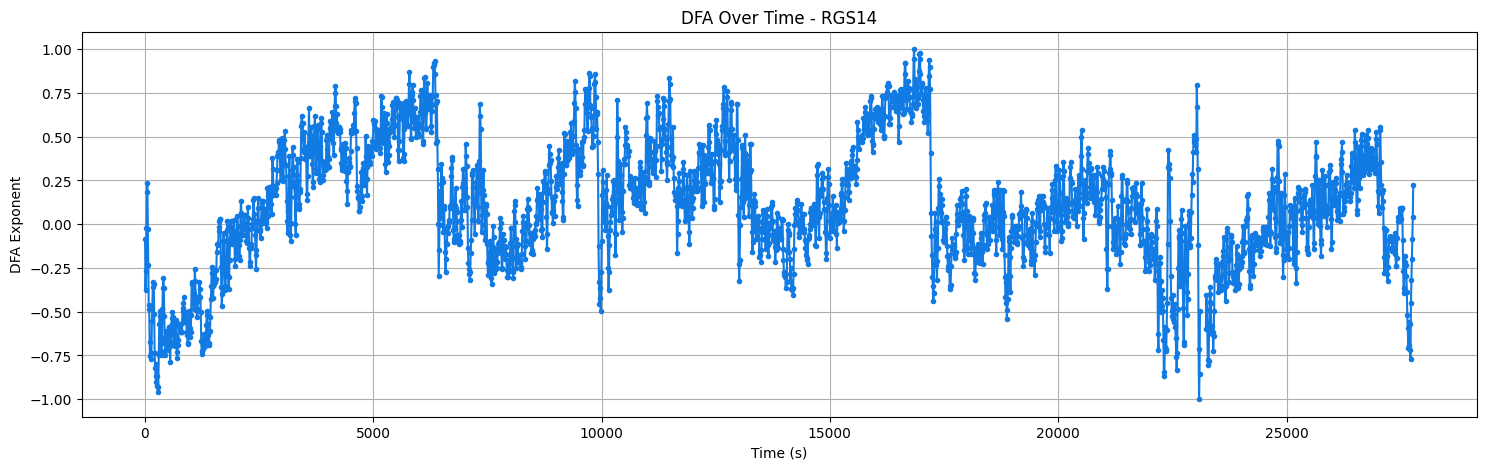

In [109]:
num_windows = (len(lfp_PFC) - window_size) // step_size + 1

dfa_exponents = []
time_stamps = []

for i in range(num_windows):
    start = i * step_size
    end = start + window_size
    segment = lfp_PFC[start:end]

    _, _, exp_window = compute_fluctuations(segment, fs, n_scales=10,
                                            min_scale=0.05, max_scale=4.0)

    dfa_exponents.append(exp_window)
    time_stamps.append((start + end) / 2 / fs)

dfa_exponents = np.array(dfa_exponents)
window_length = 11 if len(dfa_exponents) >= 11 else len(dfa_exponents) | 1  # ensure it's odd
polyorder = 4

smoothed_dfa = savgol_filter(dfa_exponents, window_length=window_length, polyorder=polyorder)
normalized_dfa = 2 * ((smoothed_dfa - min(smoothed_dfa)) /(max(smoothed_dfa) - min(smoothed_dfa))) - 1
plt.figure(figsize=(18, 5))
plt.plot(time_stamps, normalized_dfa, marker='.', linestyle='-', color=Blue)
plt.xlabel('Time (s)')
plt.ylabel('DFA Exponent')
plt.title('DFA Over Time - RGS14')
plt.grid()
plt.savefig(f"{output_dir}/DFA_over_time.svg", format='svg')
plt.show()

   state      mean       sem
0      0 -0.325594  0.020061
1      1 -0.251801  0.015340
2      2  0.188176  0.005538
3      3  0.599841  0.008249
4      4 -0.079904  0.006603


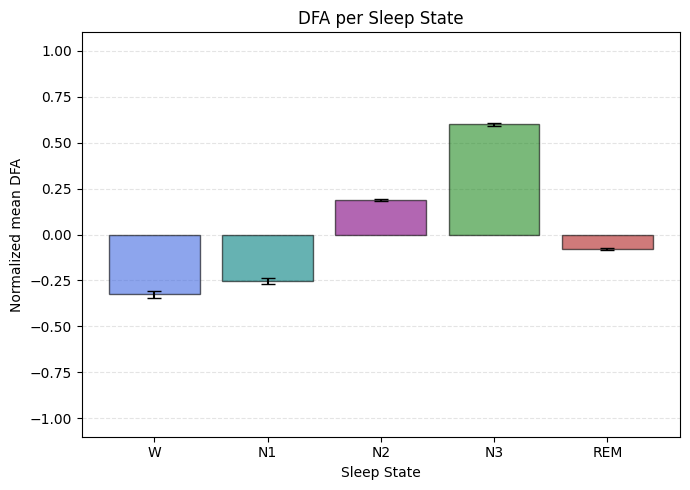

Counts per state (0..4): [347, 188, 1477, 371, 395]
Data types: int64
Counts per state (0..4): [347, 188, 1477, 371, 395]
Unique states present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Using seaborn violinplot


C:\Users\timmi\AppData\Local\Temp\ipykernel_22708\1357279209.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(
C:\Users\timmi\AppData\Local\Temp\ipykernel_22708\1357279209.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
C:\Users\timmi\AppData\Local\Temp\ipykernel_22708\1357279209.py:71: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  ax = sns.violinplot(
C:\Users\timmi\AppData\Local\Temp\ipykernel_22708\1357279209.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.

<Figure size 700x500 with 0 Axes>

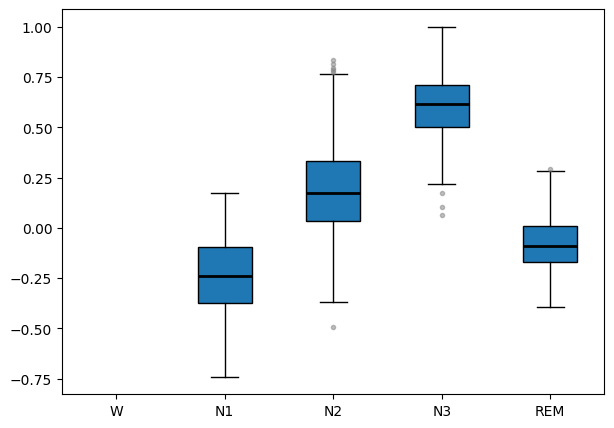

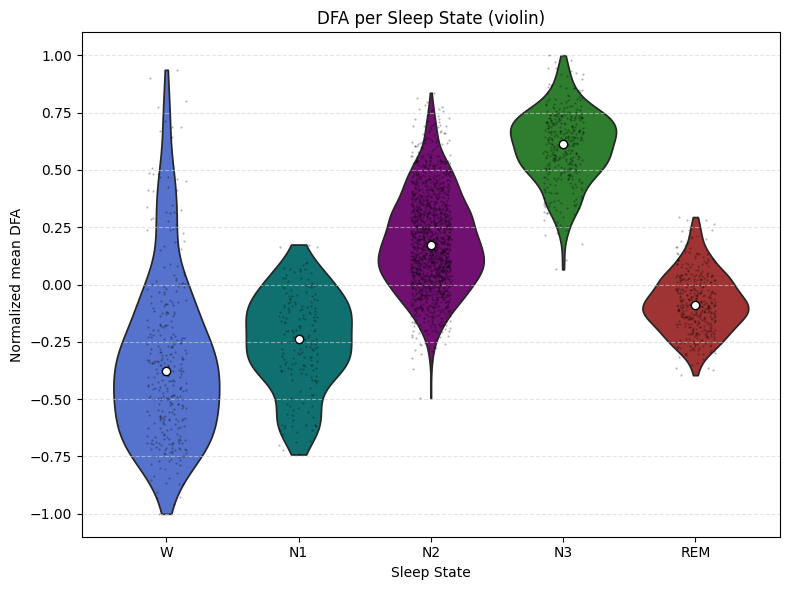

In [110]:
df = pd.DataFrame({'state': states, 'dfa': normalized_dfa})
summary = df.groupby('state')['dfa'].agg(['mean', 'sem']).reset_index()
print(summary)
plt.figure(figsize=(7, 5))
plt.bar(summary['state'], summary['mean'], yerr=summary['sem'],
        capsize=5, color=[colors[int(s)] for s in summary['state']], edgecolor='black', zorder=2, alpha=0.6)
plt.xticks([0, 1, 2, 3, 4], ['W', 'N1', 'N2', 'N3', 'REM'])
plt.ylim(-1.1, 1.1)
plt.xlabel('Sleep State')
plt.ylabel('Normalized mean DFA')
plt.title('DFA per Sleep State')
plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
plt.tight_layout()
plt.savefig(f"{output_dir}/DFA_bar.svg", format='svg')
plt.show()
plt.figure(figsize=(7, 5))
# Create a boxplot
# Build data in exact order 0..4
data_for_box = [df.loc[df['state'] == s, 'dfa'].values for s in range(5)]
counts = [len(d) for d in data_for_box]

print("Counts per state (0..4):", counts)
print("Data types:", df['state'].dtype)

# Replace truly-empty groups with an array of np.nan so boxplot draws a placeholder
# (Matplotlib sometimes skips empty lists)
data_for_box_nonempty = [d if len(d) > 0 else np.array([np.nan]) for d in data_for_box]

plt.figure(figsize=(7, 5))
bp = plt.boxplot(
    data_for_box_nonempty,
    labels=labels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markersize=3, markerfacecolor='gray', markeredgecolor='gray', alpha=0.5)
)

# try seaborn first
use_seaborn = True
try:
    import seaborn as sns
except Exception:
    use_seaborn = False

# your inputs
colors = {0: 'royalblue', 1: 'teal', 2: 'purple', 3: 'forestgreen', 4: 'firebrick'}
labels = ['W', 'N1', 'N2', 'N3', 'REM']
all_states = list(range(5))

# Build data in exact order 0..4
data_for_box = [df.loc[df['state'] == s, 'dfa'].values for s in all_states]
counts = [len(d) for d in data_for_box]
print("Counts per state (0..4):", counts)
print("Unique states present:", sorted(df['state'].unique()))

# Make a copy of df for plotting convenience
df_plot = df.copy()
df_plot['state'] = df_plot['state'].astype(int)

if use_seaborn:
    print("Using seaborn violinplot")
    plt.figure(figsize=(8, 6))

    # seaborn expects the state column to be categorical strings or ints; we keep ints but pass order
    # Create palette list in the 0..4 order
    palette = [colors[s] for s in all_states]

    # Violinplot - drop NaNs automatically
    ax = sns.violinplot(
        x='state', y='dfa', data=df_plot,
        order=all_states,
        palette=palette,
        cut=0,          # don't show tails beyond data
        bw='scott',     # bandwidth estimator (tune if needed)
        inner=None      # we'll overlay medians ourselves
    )

    # overlay a stripplot (points) for verification (jittered)
    sns.stripplot(x='state', y='dfa', data=df_plot, order=all_states,
                  color='k', size=1.5, jitter=0.15, alpha=0.3)

    # compute medians and plot
    medians = [np.nanmedian(d) if len(d)>0 else np.nan for d in data_for_box]
    for i, m in enumerate(medians):
        if not np.isnan(m):
            plt.plot(i, m, marker='o', color='white', markeredgecolor='black', markersize=6, zorder=10)

    # cosmetic
    ax.set_xticklabels(labels)
    ax.set_xlabel('Sleep State')
    ax.set_ylabel('Normalized mean DFA')
    ax.set_ylim(-1.1, 1.1)
    ax.set_title('DFA per Sleep State (violin)')
    plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/dfa_violin.svg", format="svg")
    plt.show()

else:
    print("Seaborn not available — using matplotlib.violinplot fallback")
    # replace empty groups with np.nan arrays so positions are preserved
    data_for_plot = [d if len(d) > 0 else np.array([np.nan]) for d in data_for_box]

    fig, ax = plt.subplots(figsize=(8, 6))
    parts = ax.violinplot(data_for_plot, positions=all_states, showmeans=False, showextrema=False, showmedians=False)

    # color each violin
    for i, pc in enumerate(parts['bodies']):
        color = colors.get(i, 'lightgray')
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(0.6)

    # overlay medians
    medians = [np.nanmedian(d) if len(d)>0 else np.nan for d in data_for_box]
    for i, m in enumerate(medians):
        if not np.isnan(m):
            ax.plot(i, m, 'o', color='white', markeredgecolor='black', markersize=6, zorder=10)

    # overlay jittered points (strip)
    for i, d in enumerate(data_for_box):
        if len(d) > 0:
            x_jitter = np.random.normal(loc=i, scale=0.06, size=len(d))
            ax.scatter(x_jitter, d, s=4, color='k', alpha=0.25, zorder=5)

    ax.set_xticks(all_states)
    ax.set_xticklabels(labels)
    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel('Sleep State')
    ax.set_ylabel('Normalized mean DFA')
    ax.set_title('DFA per Sleep State (violin fallback)')
    ax.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/dfa_violin.svg", format="svg")
    plt.show()

In [111]:

for s in range(5):
    print(f"State {s}: {len(df.loc[df['state'] == s, 'dfa'])} values")
    
print(df['state'].dtype)
print(df['state'].unique())

print(df.loc[df['state'] == 0, 'dfa'].describe())

State 0: 347 values
State 1: 188 values
State 2: 1477 values
State 3: 371 values
State 4: 395 values
int64
[0 1 4 2 3]
count    335.000000
mean      -0.325594
std        0.367176
min       -1.000000
25%       -0.590875
50%       -0.375108
75%       -0.133649
max        0.936500
Name: dfa, dtype: float64


## MSE

 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

C:\Users\timmi\miniconda3\Lib\site-packages\EntropyHub\_IncrEn.py:69: RuntimeWarning: divide by zero encountered in divide
  Qk = np.minimum(R, np.floor(abs(Vk)*R/Temp))


 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

C:\Users\timmi\miniconda3\Lib\site-packages\EntropyHub\_IncrEn.py:69: RuntimeWarning: divide by zero encountered in divide
  Qk = np.minimum(R, np.floor(abs(Vk)*R/Temp))
C:\Users\timmi\miniconda3\Lib\site-packages\EntropyHub\_IncrEn.py:69: RuntimeWarning: divide by zero encountered in divide
  Qk = np.minimum(R, np.floor(abs(Vk)*R/Temp))
C:\Users\timmi\miniconda3\Lib\site-packages\EntropyHub\_IncrEn.py:69: RuntimeWarning: divide by zero encountered in divide
  Qk = np.minimum(R, np.floor(abs(Vk)*R/Temp))
C:\Users\timmi\miniconda3\Lib\site-packages\EntropyHub\_IncrEn.py:69: RuntimeWarning: divide by zero encountered in divide
  Qk = np.minimum(R, np.floor(abs(Vk)*R/Temp))
C:\Users\timmi\miniconda3\Lib\site-packages\EntropyHub\_IncrEn.py:69: RuntimeWarning: divide by zero encountered in divide
  Qk = np.minimum(R, np.floor(abs(Vk)*R/Temp))


 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

...

 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

C:\Users\timmi\miniconda3\Lib\site-packages\EntropyHub\_IncrEn.py:69: RuntimeWarning: divide by zero encountered in divide
  Qk = np.minimum(R, np.floor(abs(Vk)*R/Temp))
C:\Users\timmi\miniconda3\Lib\site-packages\EntropyHub\_IncrEn.py:69: RuntimeWarning: divide by zero encountered in divide
  Qk = np.minimum(R, np.floor(abs(Vk)*R/Temp))


 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

C:\Users\timmi\miniconda3\Lib\site-packages\EntropyHub\_IncrEn.py:69: RuntimeWarning: divide by zero encountered in divide
  Qk = np.minimum(R, np.floor(abs(Vk)*R/Temp))


 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

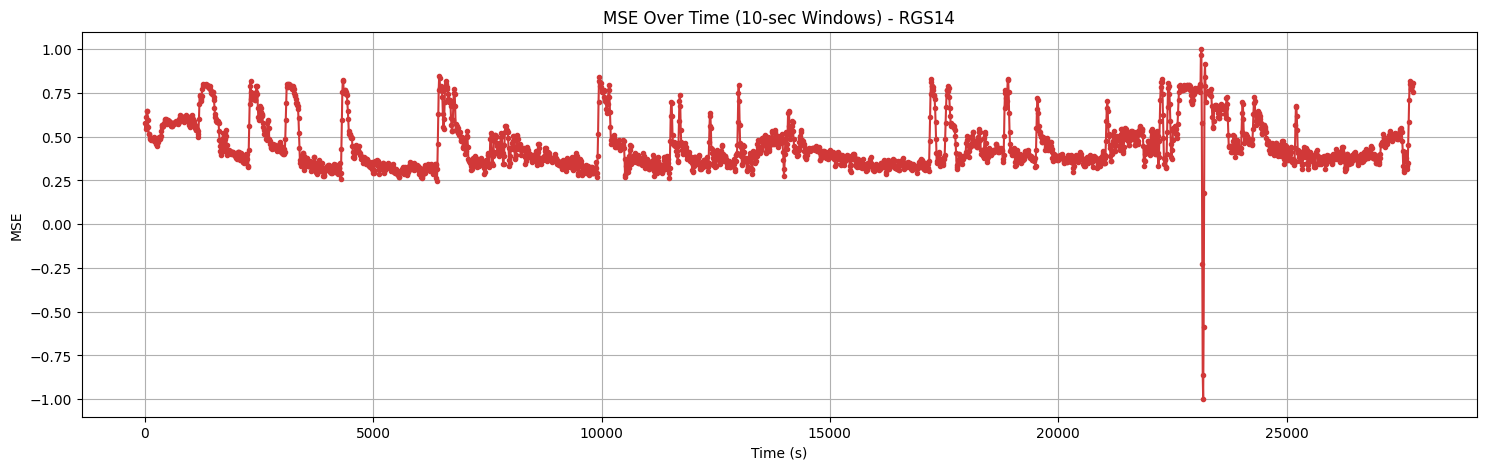

In [112]:
Mobj = EH.MSobject('IncrEn', m=2, R=3, Norm=True)

num_windows = (len(lfp_PFC) - window_size) // step_size + 1

mse_values = []
time_stamps_mse = []

for i in range(num_windows):
    start = i * step_size
    end = start + window_size
    segment = lfp_PFC[start:end]

    MSx, _ = EH.MSEn(segment, Mobj, Scales=2, Methodx='modified')

    mse_values.append(np.mean(MSx))
    time_stamps_mse.append((start + end) / 2 / fs)

mse_values = np.array(mse_values)
time_stamps_mse = np.array(time_stamps_mse)
window_length = 11 if len(mse_values) >= 11 else len(mse_values) | 1  # ensure it's odd
polyorder = 4

smoothed_mse = savgol_filter(mse_values, window_length=window_length, polyorder=polyorder)
normalized_mse = 2 * ((smoothed_mse - min(smoothed_mse)) /(max(smoothed_mse) - min(smoothed_mse))) - 1

plt.figure(figsize=(18, 5))
plt.plot(time_stamps_mse, normalized_mse, marker='.', linestyle='-', color=Red)
plt.xlabel('Time (s)')
plt.ylabel('MSE')
plt.title('MSE Over Time (10-sec Windows) - RGS14')
plt.grid()
plt.savefig(f"{output_dir}/MSE_10s.svg", format='svg')
plt.show()

   state      mean       sem
0      0  0.594738  0.010763
1      1  0.609008  0.009143
2      2  0.418973  0.002728
3      3  0.327322  0.001673
4      4  0.465049  0.003169


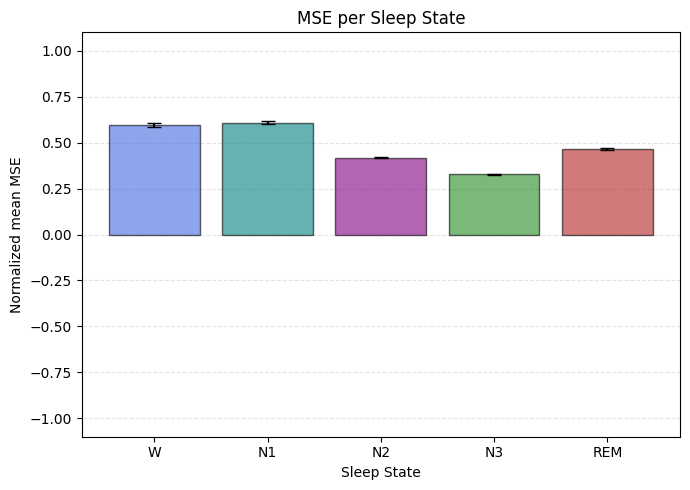

C:\Users\timmi\AppData\Local\Temp\ipykernel_22708\865539970.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


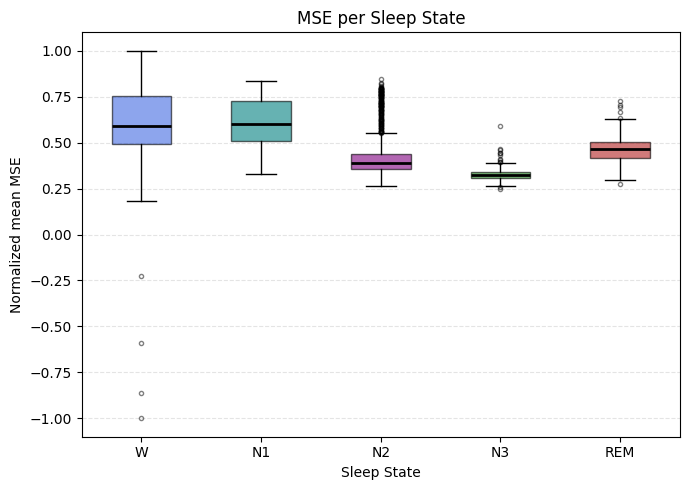

In [113]:
df = pd.DataFrame({'state': states, 'mse': normalized_mse})
summary = df.groupby('state')['mse'].agg(['mean', 'sem']).reset_index()
colors = ['royalblue', 'teal', 'purple', 'forestgreen', 'firebrick']
labels = ['W', 'N1', 'N2', 'N3', 'REM']
print(summary)
plt.figure(figsize=(7, 5))
plt.bar(summary['state'], summary['mean'], yerr=summary['sem'],
        capsize=5, color=[colors[int(s)] for s in summary['state']], edgecolor='black', zorder=2, alpha=0.6)
plt.xticks([0, 1, 2, 3, 4], ['W', 'N1', 'N2', 'N3', 'REM'])
plt.ylim(-1.1, 1.1)
plt.xlabel('Sleep State')
plt.ylabel('Normalized mean MSE')
plt.title('MSE per Sleep State')
plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
plt.tight_layout()
plt.savefig(f"{output_dir}/MSE_bar.svg", format='svg')
plt.show()
plt.figure(figsize=(7, 5))
# Create a boxplot
bp = plt.boxplot(
    [df.loc[df['state'] == s, 'mse'] for s in range(5)],
    labels=labels,
    patch_artist=True,
    boxprops=dict(facecolor='lightgray', color='black'),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markersize=3, color='gray', alpha=0.5)
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_edgecolor('black')
plt.xlabel('Sleep State')
plt.ylabel('Normalized mean MSE')
plt.ylim(-1.1, 1.1)
plt.title('MSE per Sleep State')
plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
plt.tight_layout()
plt.savefig(f"{output_dir}/MSE_box.svg", format='svg')
plt.show()

## Final Plot

C:\Users\timmi\miniconda3\Lib\site-packages\matplotlib\axes\_axes.py:8283: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


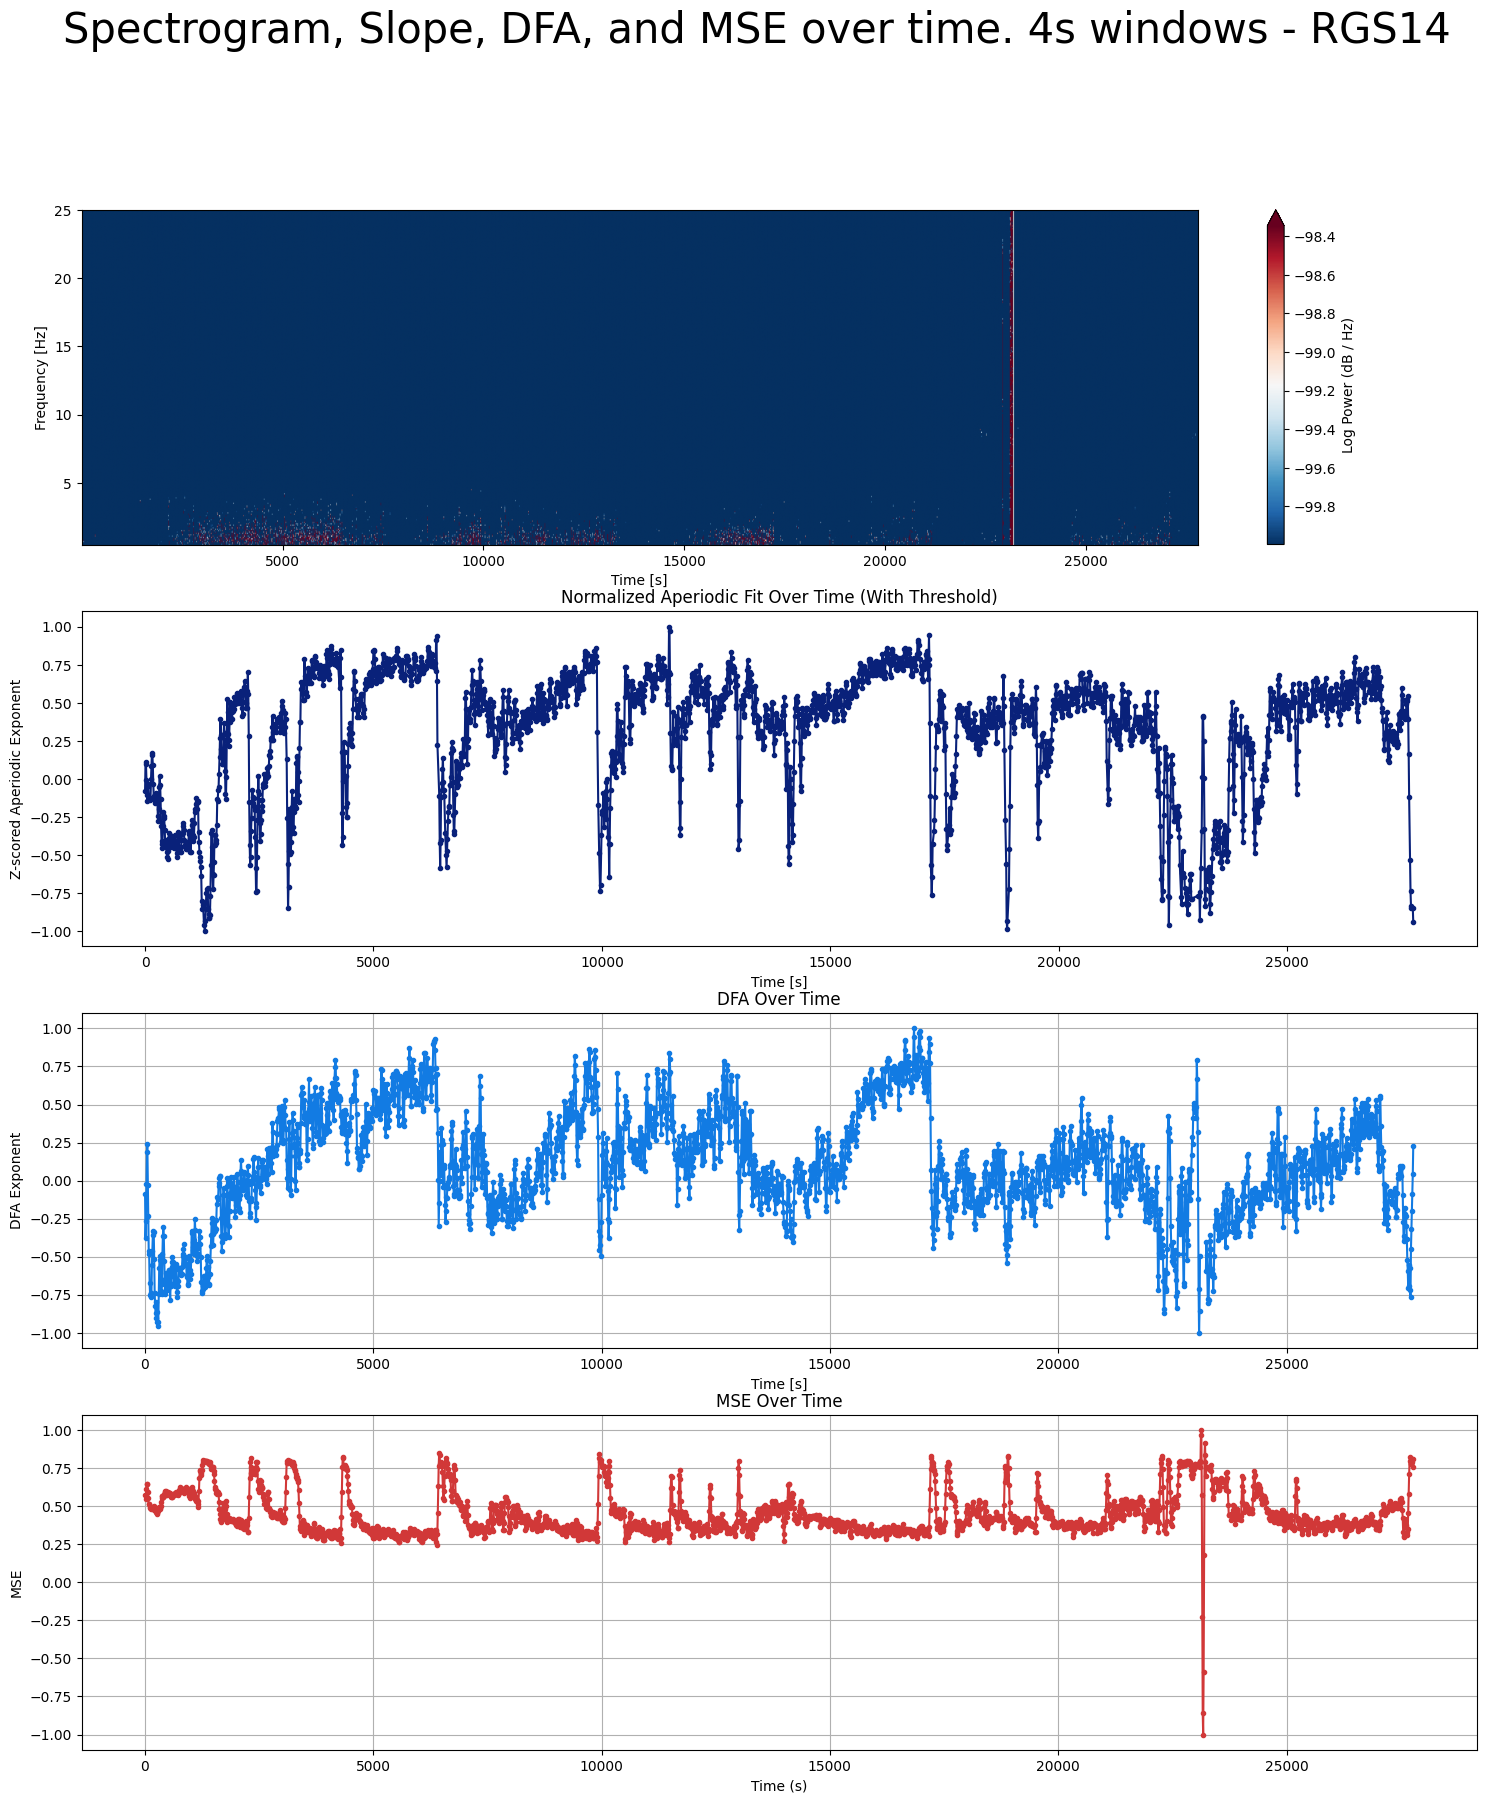

In [114]:
# SPECTROGRAM
nperseg = int(10 * fs)      # Window Size
fmin, fmax = 0.5, 25

# Create Plot
fig, axs = plt.subplots(4, 1, figsize=(18, 20))
fig.suptitle('Spectrogram, Slope, DFA, and MSE over time. 4s windows - RGS14', fontsize=30)

Pxx, freqs, bins, im = axs[0].specgram(lfp_PFC, NFFT=nperseg, Fs=fs, cmap="RdBu_r", scale="dB")

# Frequency (0.5 Hz ≤ f ≤ 25 Hz)
freq_mask = (freqs >= fmin) & (freqs <= fmax)
freqs = freqs[freq_mask]
Pxx = Pxx[freq_mask, :]

vmin, vmax = np.percentile(10 * np.log10(Pxx + 1e-10), [10, 98])
im.set_clim(vmin, vmax)

axs[0].set_ylabel("Frequency [Hz]")
axs[0].set_xlabel("Time [s]")
cbar = fig.colorbar(im, ax=axs[0], extend='max', label="Log Power (dB / Hz)")
axs[0].set_ylim(fmin, fmax)


# SLOPE
axs[1].plot(filtered_timestamps, normalized_exponents, marker='.', linestyle='-', color=DarkBlue)
axs[1].set_xlabel('Time [s]')
axs[1].set_ylabel('Z-scored Aperiodic Exponent')
axs[1].set_title('Normalized Aperiodic Fit Over Time (With Threshold)')
#axs[1].axhline(0, color='r', linestyle='--', label='Mean')
#axs[1].legend()

# DFA
axs[2].plot(time_stamps, normalized_dfa, marker='.', linestyle='-', color=Blue)
axs[2].set_xlabel('Time [s]')
axs[2].set_ylabel('DFA Exponent')
axs[2].set_title('DFA Over Time')
axs[2].grid()

axs[3].plot(time_stamps_mse, normalized_mse, marker='.', linestyle='-', color=Red)
axs[3].set_xlabel('Time (s)')
axs[3].set_ylabel('MSE')
axs[3].set_title('MSE Over Time')
axs[3].grid()
plt.savefig(f"{output_dir}/combined.svg", format='svg')
plt.show()

# 2. RGS14: Results for Epochs
-Not Suitable.

In [115]:
def find_all_state_epochs(state_array):
    """
    Returns a list of (start_sample_idx, end_sample_idx, state) tuples.
    Assumes each element in state_array represents 1 second of signal.
    """
    epochs = []
    start_idx = 0

    for i in range(1, len(state_array)):
        if state_array[i] != state_array[i - 1]:
            end_idx = i - 1
            state = state_array[start_idx]
            epochs.append((start_idx, end_idx, state))
            start_idx = i

    # Add last epoch
    epochs.append((start_idx, len(state_array) - 1, state_array[start_idx]))
    return epochs

In [116]:
samples_per_state = fs  # If state_array is per second

aperiodic_exponents = []
state_labels = []
epoch_times = []

state_epochs = find_all_state_epochs(sleep_states)

for idx, (start_sec, end_sec, state) in enumerate(state_epochs):
    # Convert to sample indices
    start_sample = start_sec * samples_per_state
    end_sample = (end_sec + 1) * samples_per_state  # +1 to include the full last second

    epoch_signal = lfp_PFC[start_sample:end_sample]

    # Skip if too short
    if len(epoch_signal) < 2 * fs:
        continue

    # Compute PSD
    freqs, psd = welch(epoch_signal, fs=fs, nperseg=4096)
    freqs, psd = freqs[freqs <= 100], psd[freqs <= 100]

    # Fit aperiodic component
    try:
        fm = SpectralModel(min_peak_height=0.05, aperiodic_mode='knee', verbose=False)
        fm.fit(freqs, psd)
        exponent = fm.get_params('aperiodic')[1]
        aperiodic_exponents.append(exponent)
        state_labels.append(state)
        epoch_times.append(idx)
    except Exception as e:
        print(f"Skipping epoch {idx} due to error: {e}")

C:\Users\timmi\AppData\Local\Temp\ipykernel_22708\3533767935.py:21: UserWarning: nperseg=4096 is greater than signal length max(len(x), len(y)) = 1000, using nperseg = 1000
  freqs, psd = welch(epoch_signal, fs=fs, nperseg=4096)
C:\Users\timmi\AppData\Local\Temp\ipykernel_22708\3533767935.py:21: UserWarning: nperseg=4096 is greater than signal length max(len(x), len(y)) = 2500, using nperseg = 2500
  freqs, psd = welch(epoch_signal, fs=fs, nperseg=4096)
C:\Users\timmi\AppData\Local\Temp\ipykernel_22708\3533767935.py:21: UserWarning: nperseg=4096 is greater than signal length max(len(x), len(y)) = 1750, using nperseg = 1750
  freqs, psd = welch(epoch_signal, fs=fs, nperseg=4096)
C:\Users\timmi\AppData\Local\Temp\ipykernel_22708\3533767935.py:21: UserWarning: nperseg=4096 is greater than signal length max(len(x), len(y)) = 3250, using nperseg = 3250
  freqs, psd = welch(epoch_signal, fs=fs, nperseg=4096)
C:\Users\timmi\AppData\Local\Temp\ipykernel_22708\3533767935.py:21: UserWarning: npe

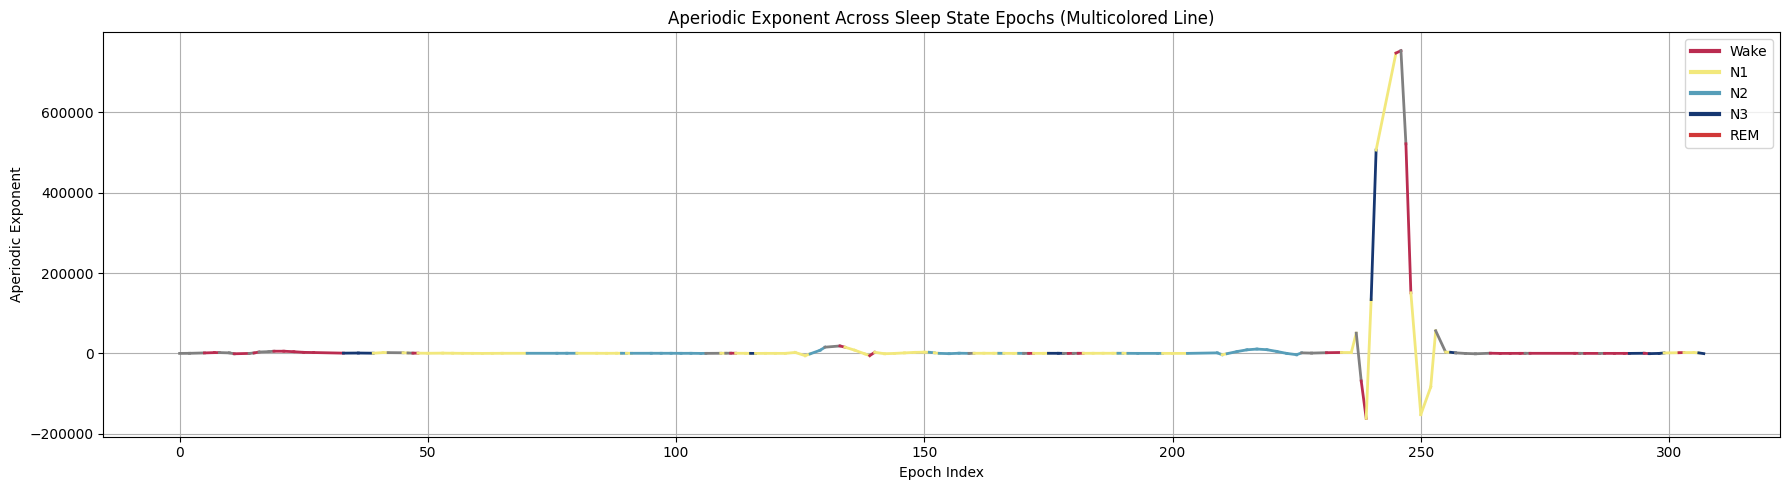

In [117]:
aperiodic_exponents = np.array(aperiodic_exponents)
state_labels = np.array(state_labels)
epoch_times = np.array(epoch_times)

# Remove outliers
threshold_min = np.percentile(aperiodic_exponents, 2)
threshold_max = np.percentile(aperiodic_exponents, 98)
valid = (aperiodic_exponents >= threshold_min) & (aperiodic_exponents <= threshold_max)

#filtered_exponents = aperiodic_exponents[valid]
#filtered_states = state_labels[valid]
#filtered_times = epoch_times[valid]

# Z-score the filtered exponents
#z_exponents = (filtered_exponents - np.mean(filtered_exponents)) / np.std(filtered_exponents)
#filtered_exponents_z = (filtered_exponents - np.mean(filtered_exponents)) / np.std(filtered_exponents)
window_length = 11 if len(aperiodic_exponents) >= 11 else len(aperiodic_exponents) | 1  # ensure it's odd
polyorder = 4

smoothed_exponents = savgol_filter(aperiodic_exponents, window_length=window_length, polyorder=polyorder)

# Color mapping for states
state_map = {1: '#BA2C50', 2: '#F2E87C', 3: '#579EB9', 4: '#163771', 5:Red}
state_names = {1: 'Wake', 2: 'N1', 3: 'N2', 4: 'N3', 5: 'REM'}
plt.figure(figsize=(18, 5))


# Plot each line segment with its state color
for i in range(min(len(epoch_times), len(smoothed_exponents)) - 1):
    x = [epoch_times[i], epoch_times[i + 1]]
    y = [smoothed_exponents[i], smoothed_exponents[i + 1]]
    state = state_labels[i]
    color = state_map.get(state, 'gray')
    plt.plot(x, y, color=color, linewidth=2)
# Mean line
#plt.axhline(0, color='red', linestyle='--', label='Mean')

plt.xlabel('Epoch Index')
plt.ylabel('Aperiodic Exponent')
plt.title('Aperiodic Exponent Across Sleep State Epochs (Multicolored Line)')
plt.grid(True)

# Legend for states
legend_elements = [plt.Line2D([0], [0], color=state_map[s], lw=3, label=state_names[s]) for s in state_map]
#legend_elements.append(plt.Line2D([0], [0], linestyle='--', color='red', label='Mean'))

plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.savefig(f"{output_dir}/Aperiodic_exp_across_sleep_States.svg", format='svg')
plt.show()

In [118]:
# First, find the epochs
epochs = find_all_state_epochs(sleep_states)  # state_array has 1 sample/sec

dfa_exponents = []
epoch_times = []
epoch_labels = []

for start_sec, end_sec, state in epochs:
    start_sample = start_sec * fs
    end_sample = (end_sec + 1) * fs  # +1 to include the last second

    segment = lfp_PFC[start_sample:end_sample]

    #if len(segment) < fs * 2:  # skip very short epochs (e.g. <5 sec)
     #   continue

    try:
        _, _, exp_epoch = compute_fluctuations(segment, fs, n_scales=10,
                                               min_scale=0.05, max_scale=4.0)
        dfa_exponents.append(exp_epoch)
        epoch_times.append((start_sample + end_sample) / 2 / fs)
        epoch_labels.append(state)
    except Exception as e:
        print(f"Skipped epoch due to error: {e}")
        continue

C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount

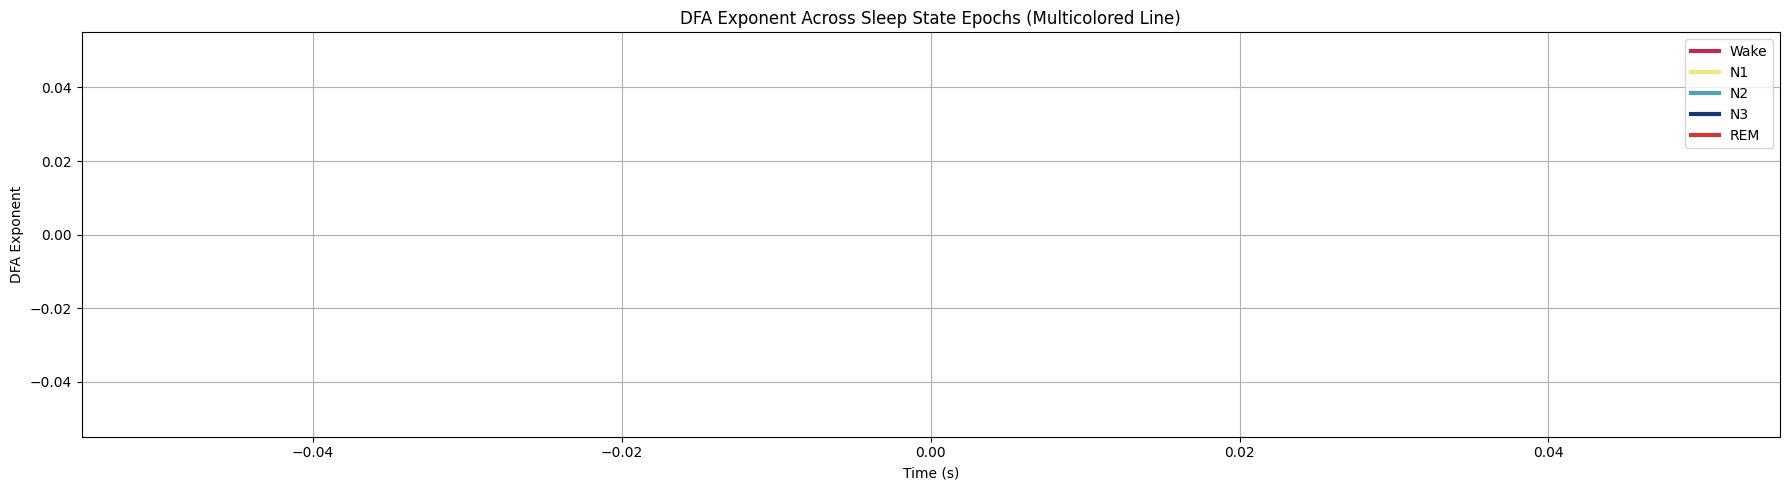

In [119]:
plt.figure(figsize=(18, 5))

window_length = 11 if len(dfa_exponents) >= 11 else len(dfa_exponents) | 1  # ensure it's odd
polyorder = 4

dfa_smoothed_exponents = savgol_filter(dfa_exponents, window_length=window_length, polyorder=polyorder)

# Plot each line segment with its state color
for i in range(len(epoch_times) - 1):
    x = [epoch_times[i], epoch_times[i + 1]]
    y = [dfa_smoothed_exponents[i], dfa_smoothed_exponents[i + 1]]
    state = epoch_labels[i]
    color = state_map.get(state, 'gray')
    plt.plot(x, y, color=color, linewidth=2)


plt.xlabel('Time (s)')
plt.ylabel('DFA Exponent')
plt.title('DFA Exponent Across Sleep State Epochs (Multicolored Line)')
plt.grid(True)

# Legend for states
legend_elements = [plt.Line2D([0], [0], color=state_map[s], lw=3, label=state_names[s]) for s in state_map]

plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

In [120]:
# Create the Multiscale Entropy object
Mobj = EH.MSobject('IncrEn', m=2, R=3, Norm=True)

# Get the sleep stage-defined epochs
epochs = find_all_state_epochs(sleep_states)

mse_values_epoch = []
epoch_times_mse = []
epoch_labels_mse = []

for start_sec, end_sec, state in epochs:
    start_sample = start_sec * fs
    end_sample = (end_sec + 1) * fs  # include the end

    segment = lfp_PFC[start_sample:end_sample]

    # Skip very short segments (e.g., <2*Scale)
    #if len(segment) < fs * 2:
    #   continue

    try:
        MSx, _ = EH.MSEn(segment, Mobj, Scales=2, Methodx='modified')
        mse_values_epoch.append(np.mean(MSx))
        epoch_times_mse.append((start_sample + end_sample) / 2 / fs)
        epoch_labels_mse.append(state)
    except Exception as e:
        print(f"Skipped epoch due to error: {e}")
        continue

 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

C:\Users\timmi\miniconda3\Lib\site-packages\EntropyHub\_IncrEn.py:69: RuntimeWarning: divide by zero encountered in divide
  Qk = np.minimum(R, np.floor(abs(Vk)*R/Temp))


 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

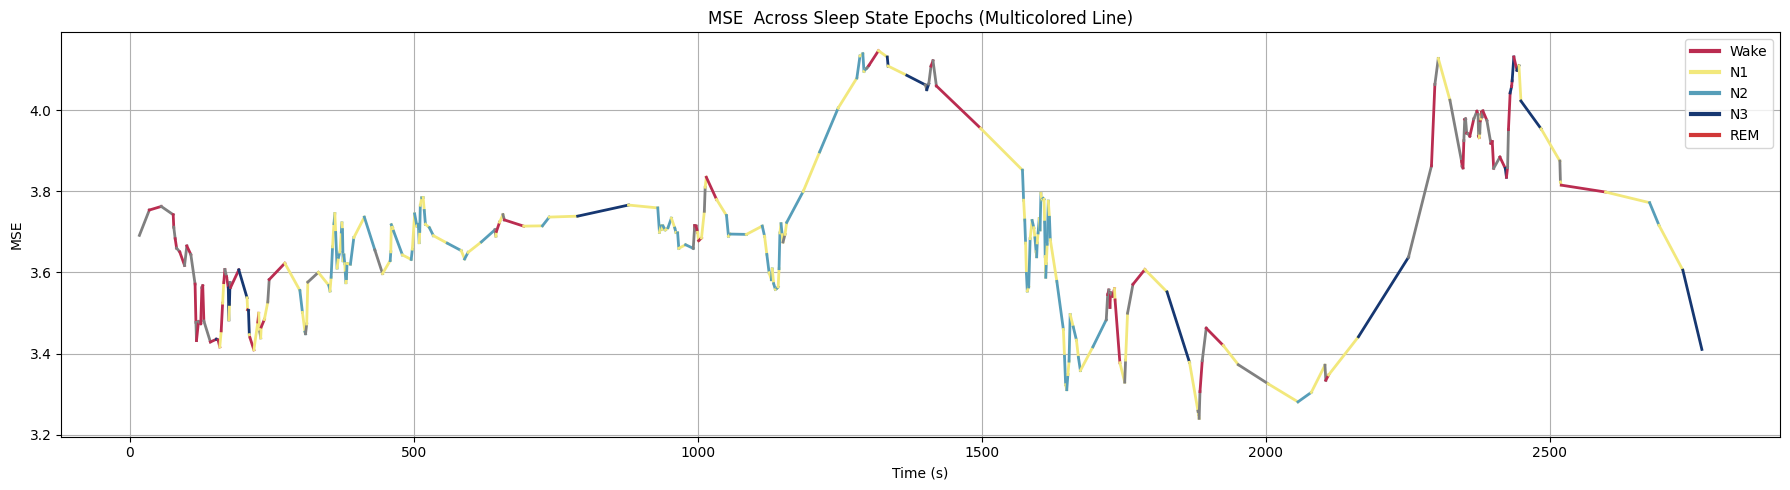

In [121]:
plt.figure(figsize=(18, 5))

window_length = 11 if len(mse_values_epoch) >= 11 else len(mse_values_epoch) | 1  # ensure it's odd
polyorder = 4

mse_smoothed_exponents = savgol_filter(mse_values_epoch, window_length=window_length, polyorder=polyorder)

# Plot each line segment with its state color
for i in range(len(epoch_times_mse) - 1):
    x = [epoch_times_mse[i], epoch_times_mse[i + 1]]
    y = [mse_smoothed_exponents[i], mse_smoothed_exponents[i + 1]]
    state = epoch_labels_mse[i]
    color = state_map.get(state, 'gray')
    plt.plot(x, y, color=color, linewidth=2)


plt.xlabel('Time (s)')
plt.ylabel('MSE')
plt.title('MSE  Across Sleep State Epochs (Multicolored Line)')
plt.grid(True)

# Legend for states
legend_elements = [plt.Line2D([0], [0], color=state_map[s], lw=3, label=state_names[s]) for s in state_map]

plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

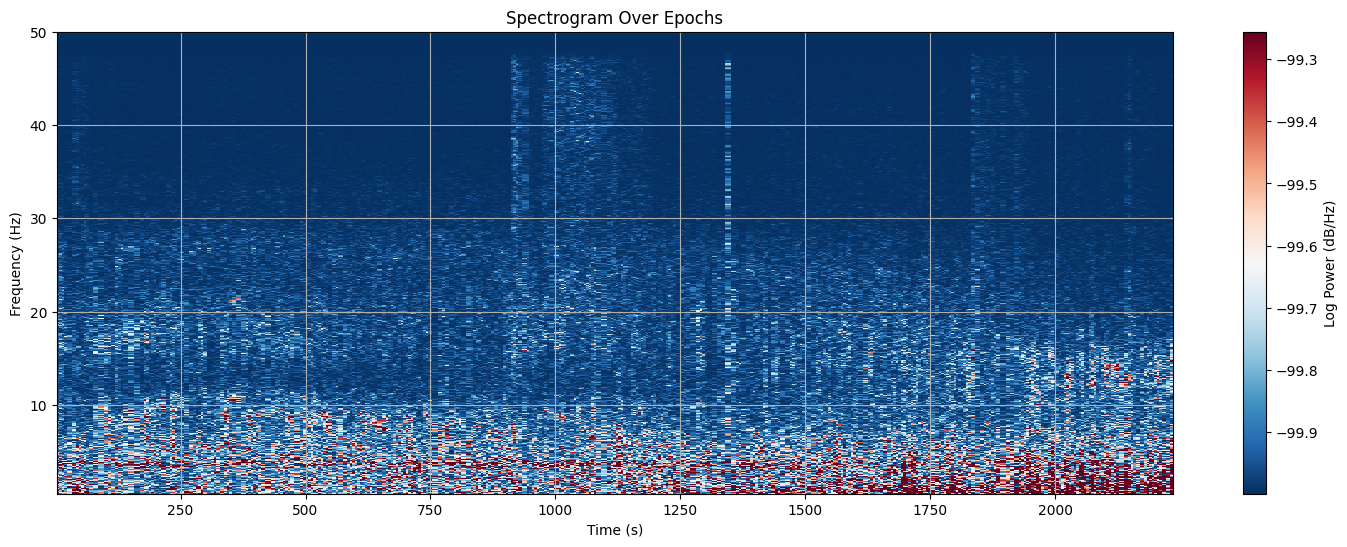

In [122]:
from scipy.signal import spectrogram

fmin, fmax = 0.5, 50
nperseg = int(10 * fs)
noverlap = nperseg // 2

# Get epochs
epochs = find_all_state_epochs(sleep_states)

# Init for concatenating results
spec_data = []
spec_times = []
spec_freqs = None
spec_colors = []

time_cursor = 0  # tracks where to place each epoch’s spectrogram

for start_sec, end_sec, state in epochs:
    start_sample = start_sec * fs
    end_sample = (end_sec + 1) * fs
    segment = lfp_PFC[start_sample:end_sample]

    # Skip too short segments
    if len(segment) < nperseg:
        continue

    f, t, Sxx = spectrogram(segment, fs=fs, nperseg=nperseg, noverlap=noverlap)

    # Filter frequencies
    freq_mask = (f >= fmin) & (f <= fmax)
    Sxx = Sxx[freq_mask, :]
    f = f[freq_mask]

    if spec_freqs is None:
        spec_freqs = f

    # Time correction to place each epoch properly on x-axis
    corrected_t = t + time_cursor
    spec_times.append(corrected_t)
    spec_data.append(Sxx)
    spec_colors.append(state)

    time_cursor += (len(segment) / fs)

# Concatenate
spec_data = np.concatenate(spec_data, axis=1)
spec_times = np.concatenate(spec_times)

# Convert to dB scale
Sxx_dB = 10 * np.log10(spec_data + 1e-10)

# Plot
plt.figure(figsize=(18, 6))
im = plt.pcolormesh(spec_times, spec_freqs, Sxx_dB, shading='auto', cmap='RdBu_r')
vmin, vmax = np.percentile(Sxx_dB, [10, 98])
im.set_clim(vmin, vmax)
plt.colorbar(label='Log Power (dB/Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.ylim(fmin, fmax)
plt.title('Spectrogram Over Epochs')
plt.grid()
plt.show()

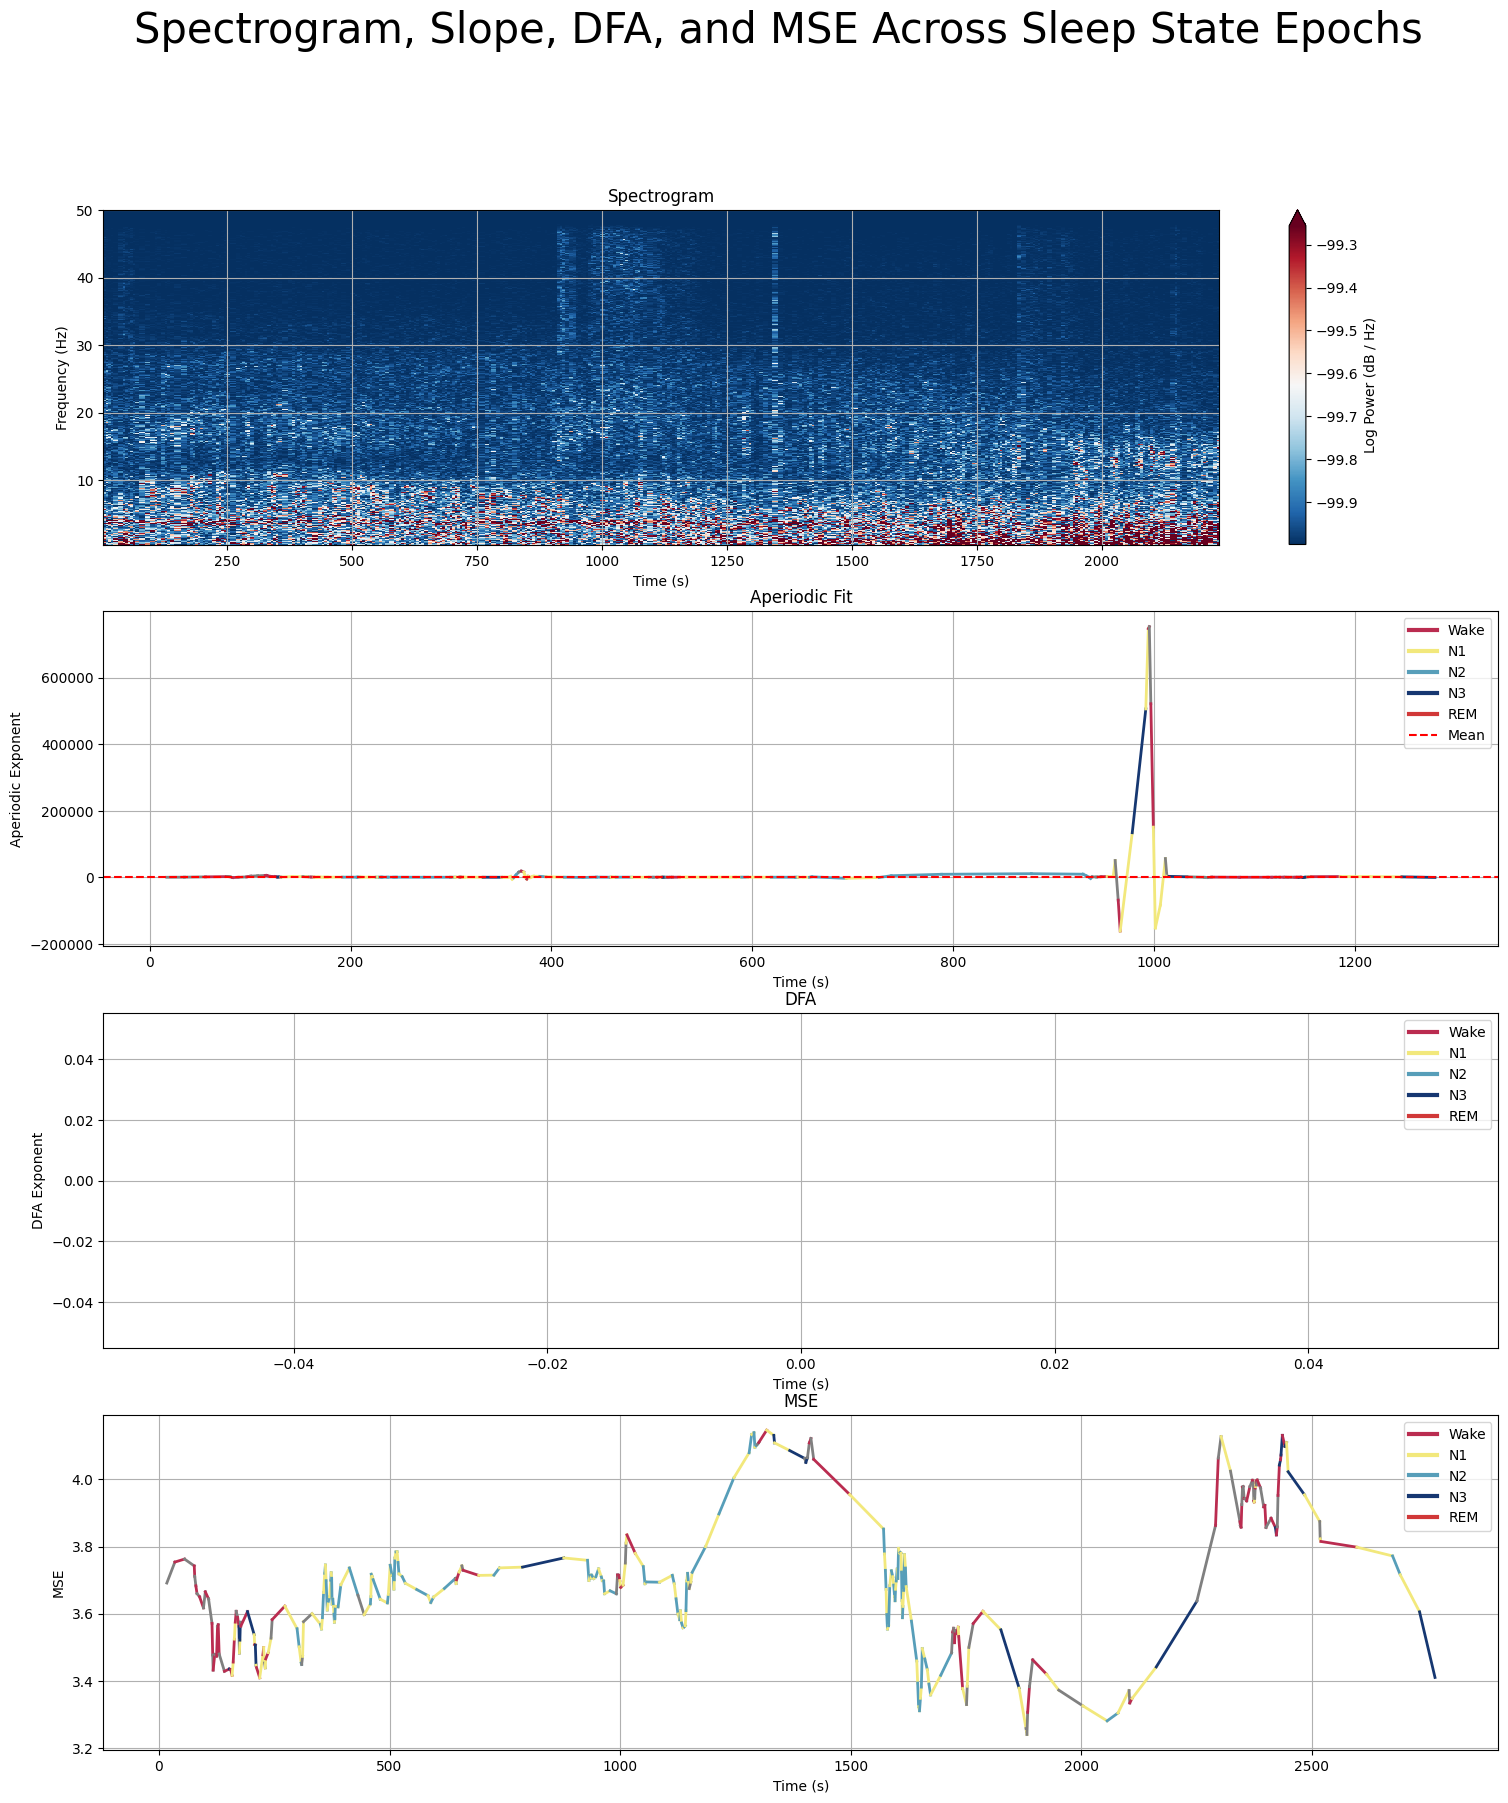

In [123]:
fig, axs = plt.subplots(4, 1, figsize=(18, 20))
fig.suptitle('Spectrogram, Slope, DFA, and MSE Across Sleep State Epochs', fontsize=30)

#SPECTROGRAM
im = axs[0].pcolormesh(spec_times, spec_freqs, Sxx_dB, shading='auto', cmap='RdBu_r')
vmin, vmax = np.percentile(Sxx_dB, [10, 98])
im.set_clim(vmin, vmax)
cbar = fig.colorbar(im, ax=axs[0], extend='max', label="Log Power (dB / Hz)")
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Frequency (Hz)')
axs[0].set_title('Spectrogram')
axs[0].grid()

# --- SLOPE ---
epoch_times_slope = epoch_times[:len(smoothed_exponents)]
for i in range(len(epoch_times_slope) - 1):
    x = [epoch_times_slope[i], epoch_times_slope[i + 1]]
    y = [smoothed_exponents[i], smoothed_exponents[i + 1]]
    state = state_labels[i]
    color = state_map.get(state, 'gray')
    axs[1].plot(x, y, color=color, linewidth=2)

axs[1].axhline(0, color='red', linestyle='--', label='Mean')

axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Aperiodic Exponent')
axs[1].set_title('Aperiodic Fit')
axs[1].grid(True)

legend_elements = [plt.Line2D([0], [0], color=state_map[s], lw=3, label=state_names[s]) for s in state_map]
legend_elements.append(plt.Line2D([0], [0],  linestyle='--', color='red', label='Mean'))

axs[1].legend(handles=legend_elements, loc='upper right')

# --- DFA ---
epoch_times_dfa = epoch_times[:len(dfa_smoothed_exponents)]
for i in range(len(epoch_times_dfa) - 1):
    x = [epoch_times_dfa[i], epoch_times_dfa[i + 1]]
    y = [dfa_smoothed_exponents[i], dfa_smoothed_exponents[i + 1]]
    state = epoch_labels[i]
    color = state_map.get(state, 'gray')
    axs[2].plot(x, y, color=color, linewidth=2)

axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('DFA Exponent')
axs[2].set_title('DFA')
axs[2].grid(True)

legend_elements = [plt.Line2D([0], [0], color=state_map[s], lw=3, label=state_names[s]) for s in state_map]

axs[2].legend(handles=legend_elements, loc='upper right')

# --- MSE ---
epoch_times_mse = epoch_times_mse[:len(mse_smoothed_exponents)]
for i in range(len(epoch_times_mse) - 1):
    x = [epoch_times_mse[i], epoch_times_mse[i + 1]]
    y = [mse_smoothed_exponents[i], mse_smoothed_exponents[i + 1]]
    state = epoch_labels_mse[i]
    color = state_map.get(state, 'gray')
    axs[3].plot(x, y, color=color, linewidth=2)


axs[3].set_xlabel('Time (s)')
axs[3].set_ylabel('MSE')
axs[3].set_title('MSE')
axs[3].grid(True)

# Legend for states
legend_elements = [plt.Line2D([0], [0], color=state_map[s], lw=3, label=state_names[s]) for s in state_map]

axs[3].legend(handles=legend_elements, loc='upper right')
plt.savefig(f"{output_dir}/spec_slope_dfa_mse.svg", format='svg')
plt.show()

# OS Basic: Results for windowing (4s windows)

In [124]:
fs_osb = 250
window_size = 4 * fs_osb
step_size = window_size  # In case we wanted overlap later.

## Aperiodic Fit

In [125]:
num_windows = len(lfp_OSB) // window_size
time_stamps = np.arange(num_windows) * 4

aperiodic_exponents = []

for i in range(num_windows):
    start, end = i * window_size, (i + 1) * window_size
    window_data = lfp_OSB[start:end]

    freqs, psd = welch(window_data, fs=fs_osb, nperseg=1024)

    mask = (freqs <= 100)
    freqs, psd = freqs[mask], psd[mask]

    fm = SpectralModel(min_peak_height=0.05, aperiodic_mode='knee', verbose=False)
    fm.fit(freqs, psd)

    aperiodic_exponents.append(fm.get_params('aperiodic')[1])

aperiodic_exponents = np.array(aperiodic_exponents)

# Thresholding to remove outliers
threshold_min = np.percentile(aperiodic_exponents, 2)
threshold_max = np.percentile(aperiodic_exponents, 98)
valid_indices = (aperiodic_exponents >= threshold_min) & (aperiodic_exponents <= threshold_max)

filtered_exponents = aperiodic_exponents[valid_indices]
filtered_timestamps = time_stamps[valid_indices]

#filtered_exponents_z = (filtered_exponents - np.mean(filtered_exponents)) / np.std(filtered_exponents)
window_length = 11 if len(filtered_exponents) >= 11 else len(filtered_exponents) | 1  # ensure it's odd
polyorder = 4

smoothed_exponents = savgol_filter(filtered_exponents, window_length=window_length, polyorder=polyorder)
normalized_exponents = 2 * ((smoothed_exponents - min(smoothed_exponents)) /(max(smoothed_exponents) - min(smoothed_exponents))) - 1

plt.figure(figsize=(18, 5))
plt.plot(filtered_timestamps, normalized_exponents, marker='.', linestyle='-', color=DarkBlue)
plt.xlabel('Time (s)')
plt.ylabel('Aperiodic Exponent')
plt.title('Normalized Aperiodic Fit Over Time (With Threshold) - OS Basic')
#plt.axhline(0, color='r', linestyle='--', label='Mean')
#plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'lfp_OSB' is not defined

## DFA

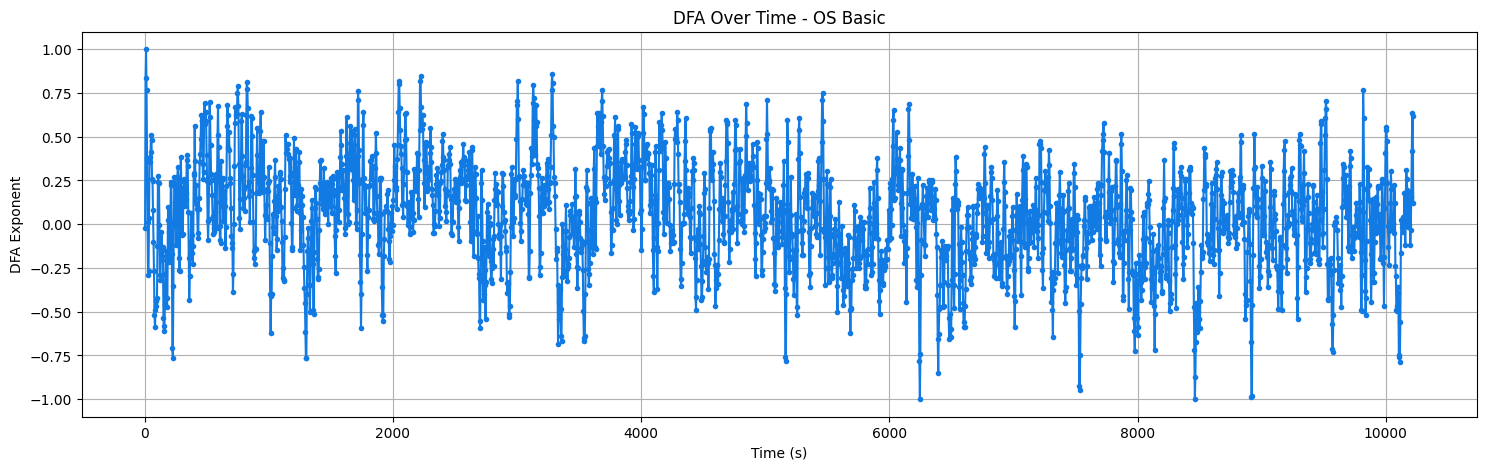

In [ ]:
num_windows = (len(lfp_OSB) - window_size) // step_size + 1

dfa_exponents = []
time_stamps = []

for i in range(num_windows):
    start = i * step_size
    end = start + window_size
    segment = lfp_OSB[start:end]

    _, _, exp_window = compute_fluctuations(segment, fs_osb, n_scales=10,
                                            min_scale=0.05, max_scale=4.0)

    dfa_exponents.append(exp_window)
    time_stamps.append((start + end) / 2 / fs_osb)

dfa_exponents = np.array(dfa_exponents)
window_length = 11 if len(dfa_exponents) >= 11 else len(dfa_exponents) | 1  # ensure it's odd
polyorder = 4

smoothed_dfa = savgol_filter(dfa_exponents, window_length=window_length, polyorder=polyorder)
normalized_dfa = 2 * ((smoothed_dfa - min(smoothed_dfa)) /(max(smoothed_dfa) - min(smoothed_dfa))) - 1
plt.figure(figsize=(18, 5))
plt.plot(time_stamps, normalized_dfa, marker='.', linestyle='-', color=Blue)
plt.xlabel('Time (s)')
plt.ylabel('DFA Exponent')
plt.title('DFA Over Time - OS Basic')
plt.grid()
plt.show()

## MSE

 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

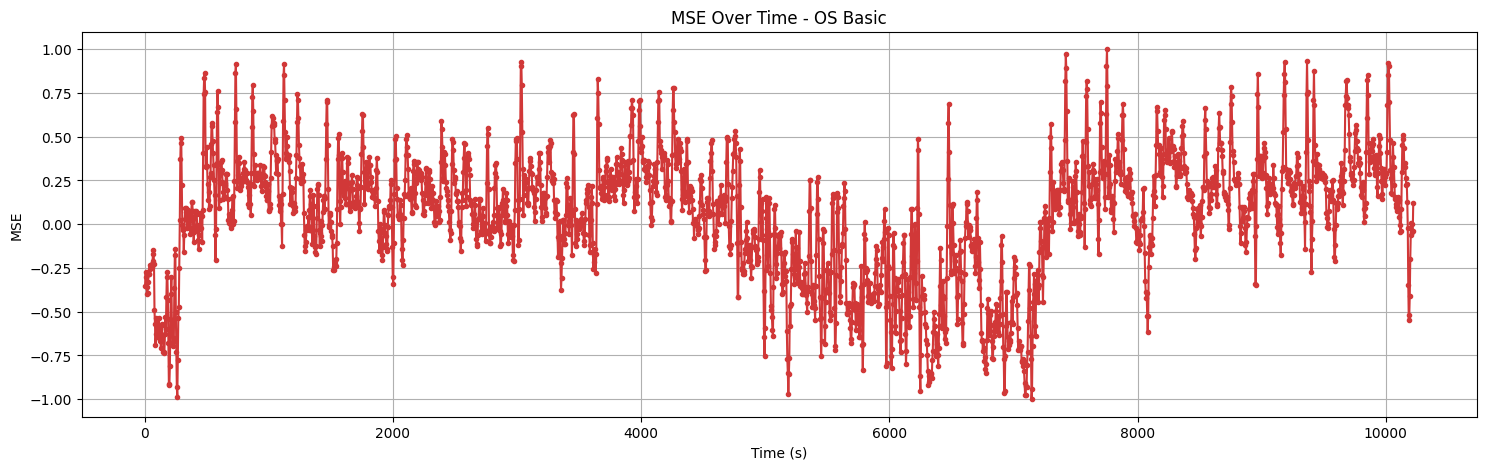

In [ ]:
Mobj = EH.MSobject('IncrEn', m=2, R=3, Norm=True)

num_windows = (len(lfp_OSB) - window_size) // step_size + 1

mse_values = []
time_stamps_mse = []

for i in range(num_windows):
    start = i * step_size
    end = start + window_size
    segment = lfp_OSB[start:end]

    MSx, _ = EH.MSEn(segment, Mobj, Scales=2, Methodx='modified')

    mse_values.append(np.mean(MSx))
    time_stamps_mse.append((start + end) / 2 / fs_osb)

mse_values = np.array(mse_values)
time_stamps_mse = np.array(time_stamps_mse)
window_length = 11 if len(mse_values) >= 11 else len(mse_values) | 1  # ensure it's odd
polyorder = 4

smoothed_mse = savgol_filter(mse_values, window_length=window_length, polyorder=polyorder)
normalized_mse = 2 * ((smoothed_mse - min(smoothed_mse)) /(max(smoothed_mse) - min(smoothed_mse))) - 1

plt.figure(figsize=(18, 5))
plt.plot(time_stamps_mse, normalized_mse, marker='.', linestyle='-', color=Red)
plt.xlabel('Time (s)')
plt.ylabel('MSE')
plt.title('MSE Over Time - OS Basic')
plt.grid()
plt.show()

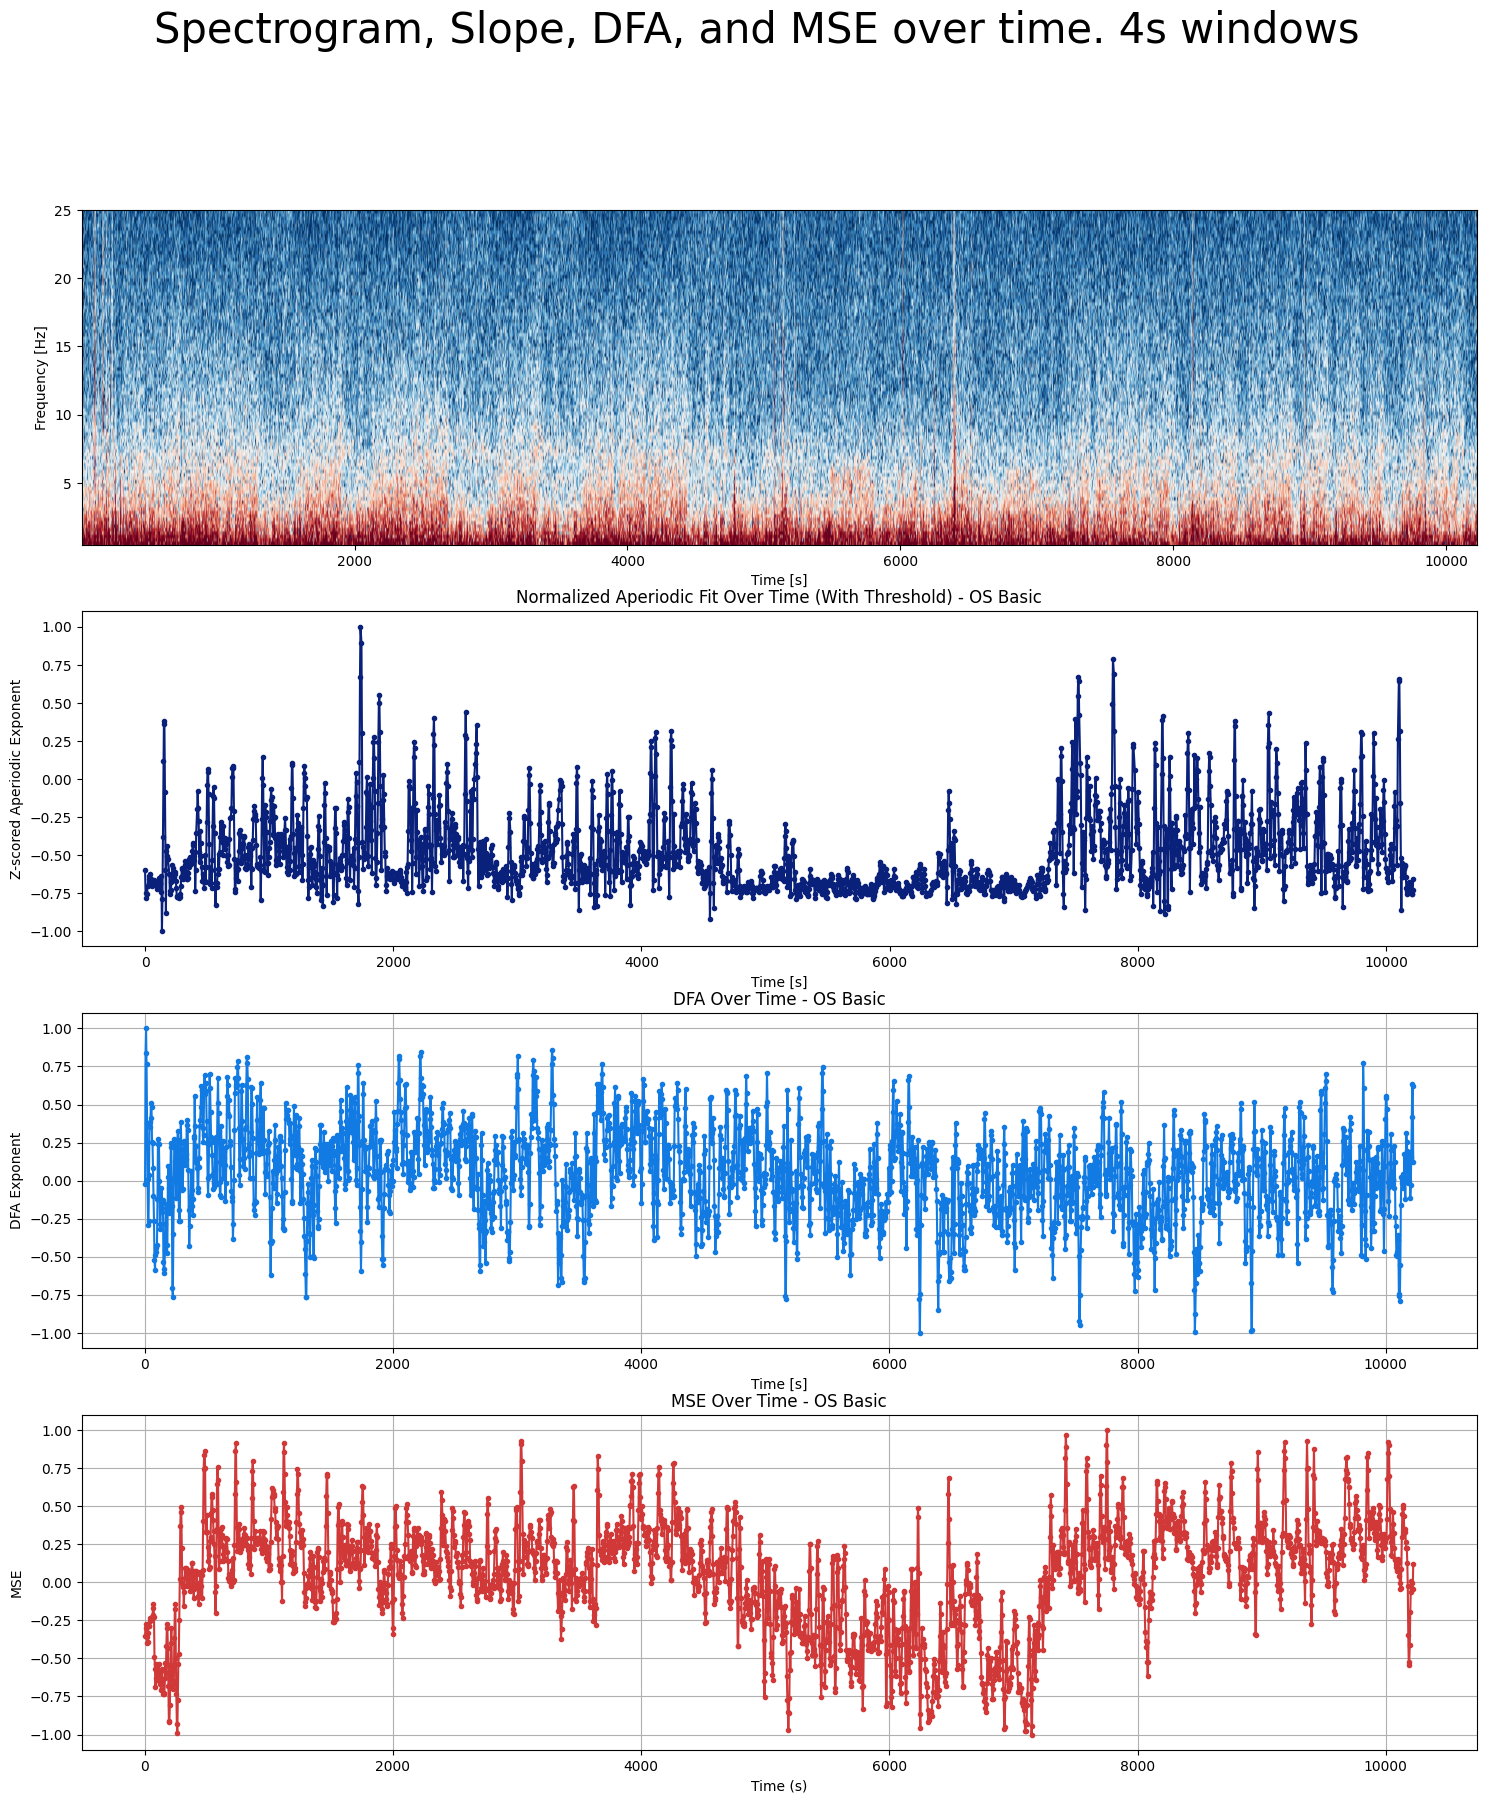

In [ ]:
# SPECTROGRAM
nperseg = int(4 * fs_osb)      # Window Size
fmin, fmax = 0.5, 25

# Create Plot
fig, axs = plt.subplots(4, 1, figsize=(18, 20))
fig.suptitle('Spectrogram, Slope, DFA, and MSE over time. 4s windows - OS Basic', fontsize=30)

Pxx, freqs, bins, im = axs[0].specgram(lfp_OSB, NFFT=nperseg, Fs=fs_osb, cmap="RdBu_r", scale="dB")

# Frequency (0.5 Hz ≤ f ≤ 25 Hz)
freq_mask = (freqs >= fmin) & (freqs <= fmax)
freqs = freqs[freq_mask]
Pxx = Pxx[freq_mask, :]

vmin, vmax = np.percentile(10 * np.log10(Pxx + 1e-10), [10, 98])
im.set_clim(vmin, vmax)

axs[0].set_ylabel("Frequency [Hz]")
axs[0].set_xlabel("Time [s]")
#cbar = fig.colorbar(im, ax=axs[0], extend='max', label="Log Power (dB / Hz)")
axs[0].set_ylim(fmin, fmax)


# SLOPE
axs[1].plot(filtered_timestamps, normalized_exponents, marker='.', linestyle='-', color=DarkBlue)
axs[1].set_xlabel('Time [s]')
axs[1].set_ylabel('Z-scored Aperiodic Exponent')
axs[1].set_title('Normalized Aperiodic Fit Over Time (With Threshold) - OS Basic')
#axs[1].axhline(0, color='r', linestyle='--', label='Mean')
#axs[1].legend()

# DFA
axs[2].plot(time_stamps, normalized_dfa, marker='.', linestyle='-', color=Blue)
axs[2].set_xlabel('Time [s]')
axs[2].set_ylabel('DFA Exponent')
axs[2].set_title('DFA Over Time - OS Basic')
axs[2].grid()

axs[3].plot(time_stamps_mse, normalized_mse, marker='.', linestyle='-', color=Red)
axs[3].set_xlabel('Time (s)')
axs[3].set_ylabel('MSE')
axs[3].set_title('MSE Over Time - OS Basic')
axs[3].grid()

plt.show()